# Braintree Dataset Exploration

This notebook provides a comprehensive overview of the Braintree dataset, which contains stereo-electroencephalography (sEEG) recordings from patients watching movies. The dataset includes neural recordings aligned with linguistic features, visual annotations, and anatomical localizations.

## Dataset Overview

The Braintree dataset consists of:
- **Neural recordings**: sEEG data from multiple subjects watching movies
- **Linguistic annotations**: Word-level features including POS tags, dependency relations, and acoustic features
- **Synchronization data**: Timing information to align neural signals with movie content
- **Electrode metadata**: Labels and 3D coordinates for each electrode
- **Visual annotations**: Scene labels and speaker information
- **Syntactic structures**: Dependency parsing trees in CoNLL-U format


In [1]:
# Import necessary libraries
import os
import json
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## 1. Dataset Structure


In [2]:
# Set root directory
root_dir = os.path.join(os.getcwd(), "..", "braintree")
print(f"Root directory: {root_dir}")
print("\nDataset structure:")
print("- all_subject_data/ : Neural recordings (H5 files)")
print("- subject_metadata/ : Trial metadata (JSON files)")
print("- subject_timings/ : Synchronization timings (CSV files)")
print("- transcripts/ : Word-level features (CSV files)")
print("- electrode_labels/ : Electrode names/labels (JSON files)")
print("- localization/ : 3D electrode coordinates (CSV files)")
print("- speaker_annotations/ : Speaker information (CSV files)")
print("- scene_annotations/ : Visual scene labels (JSON file)")
print("- trees/ : Dependency parsing trees (CoNLL-U files)")


Root directory: c:\Users\User\Documents\UNI\BRAIN\neuroprobe\..\braintree

Dataset structure:
- all_subject_data/ : Neural recordings (H5 files)
- subject_metadata/ : Trial metadata (JSON files)
- subject_timings/ : Synchronization timings (CSV files)
- transcripts/ : Word-level features (CSV files)
- electrode_labels/ : Electrode names/labels (JSON files)
- localization/ : 3D electrode coordinates (CSV files)
- speaker_annotations/ : Speaker information (CSV files)
- scene_annotations/ : Visual scene labels (JSON file)
- trees/ : Dependency parsing trees (CoNLL-U files)


## 2. Subject Metadata

Each trial has a metadata file that specifies which movie was shown and basic trial information.


In [3]:
# Example: Load metadata for subject 3, trial 0
sub_id = 3
trial_id = 0
metadata_file = os.path.join(root_dir, "subject_metadata", f"sub_{sub_id}_trial{trial_id:03}_metadata.json")

with open(metadata_file, 'r') as f:
    metadata = json.load(f)

print("Subject Metadata Sample:")
print(f"  Subject ID: {sub_id}")
print(f"  Trial ID: {trial_id}")
print(f"  Movie Title: {metadata.get('title', 'N/A')}")
print(f"  Movie Filename: {metadata.get('filename', 'N/A')}")
print(f"  Stimulus Type: {metadata.get('stimulus-type', 'N/A')}")
print(f"  Language: {metadata.get('language', 'N/A')}")
print("\nFull metadata:")
print(json.dumps(metadata, indent=2))


Subject Metadata Sample:
  Subject ID: 3
  Trial ID: 0
  Movie Title: Cars 2
  Movie Filename: cars-2
  Stimulus Type: movie
  Language: en

Full metadata:
{
  "stimulus-type": "movie",
  "title": "Cars 2",
  "filename": "cars-2",
  "language": "en"
}


## 3. Subject Timings (Synchronization)

The timings file synchronizes neural recording samples with movie time. It contains trigger events that map movie time to neural sample indices.


In [4]:
# Load timing data
timings_file = os.path.join(root_dir, "subject_timings", f"sub_{sub_id}_trial{trial_id:03}_timings.csv")
timings_df = pd.read_csv(timings_file)

print("Subject Timings Sample:")
print(f"  Total rows: {len(timings_df)}")
print(f"  Columns: {timings_df.columns.tolist()}")
print("\nFirst 10 rows:")
print(timings_df.head(10))
print("\nColumn descriptions:")
print("  - type: Event type (beginning, trigger, etc.)")
print("  - movie_time: Time in the movie (seconds)")
print("  - start_time/end_time: Wall clock times")
print("  - index: Neural sample index corresponding to this time")
print("  - diff: Sample difference from previous trigger")

print("\nStatistics:")
print(f"  Movie duration: {timings_df['movie_time'].max():.2f} seconds")
print(f"  Total samples: {timings_df['index'].max()}")
print(f"  Sampling rate: ~{timings_df['index'].max() / timings_df['movie_time'].max():.0f} Hz")


Subject Timings Sample:
  Total rows: 59064
  Columns: ['type', 'movie_time', 'start_time', 'end_time', 'trig_type', 'index', 'diff']

First 10 rows:
        type  movie_time     start_time       end_time  trig_type   index  \
0  beginning    0.000000  151498.821018  151499.746235     manual  723127   
1    trigger    0.083417  151499.817793  151499.834710  high_real  725169   
2    trigger    0.208542  151499.998980  151500.015133  high_real  725541   
3    trigger    0.291959  151500.064948  151500.082124  high_real  725677   
4    trigger    0.417084  151500.198573  151500.214487  high_real  725951   
5    trigger    0.500501  151500.280595  151500.297982  high_real  726119   
6    trigger    0.583917  151500.365778  151500.382628  high_real  726293   
7    trigger    0.709042  151500.497769  151500.513302  high_real  726563   
8    trigger    0.792459  151500.564838  151500.580690  high_real  726699   
9    trigger    0.917584  151500.682451  151500.699308  high_real  726941   

  

## 4. Neural Recordings (H5 Files)

The neural data is stored in HDF5 format. Each file contains sEEG recordings from multiple electrodes, sampled at 2048 Hz.


In [36]:
# Open H5 file and explore structure
neural_data_file = os.path.join(root_dir, "all_subject_data", f"sub_{sub_id}_trial{trial_id:03}.h5")
neural_data_file = os.path.join(root_dir, f"sub_{sub_id}_trial{trial_id:03}.h5")

with h5py.File(neural_data_file, 'r') as h5f:
    print("Neural Data File Structure:")
    print(f"  Keys: {list(h5f.keys())}")
    
    if 'data' in h5f:
        data_group = h5f['data']
        electrode_keys = list(data_group.keys())
        print(f"  Number of electrodes: {len(electrode_keys)}")
        print(f"  First 10 electrodes: {electrode_keys[:10]}")
        
        # Sample one electrode
        sample_electrode = electrode_keys[0]
        electrode_data = data_group[sample_electrode]
        print(f"\n  Sample electrode '{sample_electrode}':")
        print(f"    Shape: {electrode_data.shape}")
        print(f"    Dtype: {electrode_data.dtype}")
        
        # Load a small sample
        sample_data = electrode_data[:1000]  # First 1000 samples
        print(f"    Sample values (first 10): {sample_data[:10]}")
        print(f"    Mean: {np.mean(sample_data):.4f}")
        print(f"    Std: {np.std(sample_data):.4f}")
        print(f"    Min: {np.min(sample_data):.4f}")
        print(f"    Max: {np.max(sample_data):.4f}")
        
        # Calculate duration
        sampling_rate = 2048  # Hz
        duration_seconds = electrode_data.shape[0] / sampling_rate
        print(f"    Duration: {duration_seconds:.2f} seconds ({duration_seconds/60:.2f} minutes)")


Neural Data File Structure:
  Keys: ['data']
  Number of electrodes: 136
  First 10 electrodes: ['electrode_0', 'electrode_1', 'electrode_10', 'electrode_100', 'electrode_101', 'electrode_102', 'electrode_103', 'electrode_104', 'electrode_105', 'electrode_106']

  Sample electrode 'electrode_0':
    Shape: (14017056,)
    Dtype: float64
    Sample values (first 10): [60.34628824 61.40965896 56.62449073 57.68786145 59.5487602  59.81460288
 58.48538949 55.82696269 57.15617609 59.28291752]
    Mean: 20.5082
    Std: 25.7325
    Min: -21.5333
    Max: 82.9429
    Duration: 6844.27 seconds (114.07 minutes)


## 5. Transcript Features

Transcript files contain word-level features including linguistic annotations (POS tags, dependency relations), acoustic features (pitch, mel spectrograms), and visual features (pixel brightness).


In [37]:
# Load transcript features
movie_id = metadata.get('filename')
transcript_file = os.path.join(root_dir, "transcripts", movie_id, "features.csv")
transcript_df = pd.read_csv(transcript_file)

print("Transcript Features Sample:")
print(f"  Total words: {len(transcript_df)}")
print(f"  Columns: {len(transcript_df.columns)}")
print(f"  Column names: {transcript_df.columns.tolist()}")

print("\nFirst 5 words with key features:")
key_cols = ['text', 'lemma', 'pos', 'deprel', 'start', 'end', 'sentence', 'word_idx']
available_cols = [col for col in key_cols if col in transcript_df.columns]
print(transcript_df[available_cols].head(5))

print("\nFeature categories:")
print("  Linguistic:")
print("    - text, lemma: Word forms")
print("    - pos: Part-of-speech tag")
print("    - deprel: Dependency relation")
print("    - head, bin_head: Syntactic head information")
print("\n  Temporal:")
print("    - start, end: Word timing in movie (seconds)")
print("    - sentence_idx, word_idx: Position indices")
print("\n  Acoustic:")
print("    - mel, delta_mel: Mel spectrogram features")
print("    - pitch, rms, magnitude: Audio features")
print("\n  Visual:")
print("    - max_mean_pixel_brightness, mean_pixel_brightness: Frame brightness")
print("    - max_vector_magnitude, max_vector_angle: Motion features")
print("    - face_num: Number of faces detected")

print("\nSample word with all features:")
sample_word = transcript_df.iloc[0]
print(f"  Text: '{sample_word['text']}'")
print(f"  POS: {sample_word.get('pos', 'N/A')}")
print(f"  Time: {sample_word.get('start', 'N/A'):.2f} - {sample_word.get('end', 'N/A'):.2f} seconds")
print(f"  Sentence: '{sample_word.get('sentence', 'N/A')[:50]}...'")


Transcript Features Sample:
  Total words: 11407
  Columns: 43
  Column names: ['Unnamed: 0', 'text', 'lemma', 'pos', 'deprel', 'start', 'end', 'sentence', 'head', 'bin_head', 'sentence_idx', 'word_idx', 'prev_word_idx', 'idx_in_sentence', 'gpt2_surprisal', 'word_length', 'word_diff', 'onset_diff', 'is_onset', 'syllable', 'phoneme_num', 'charecter_num', 'mel', 'delta_mel', 'rms', 'pitch', 'magnitude', 'delta_rms', 'delta_pitch', 'delta_magnitude', 'max_mean_pixel_brightness', 'mean_pixel_brightness', 'min_mean_pixel_brightness', 'max_mean_pixel_difference', 'min_mean_pixel_difference', 'max_global_magnitude', 'max_global_angle', 'max_vector_magnitude', 'max_vector_angle', 'face_num', 'max_mean_magnitude', 'max_median_magnitude', 'speaker']

First 5 words with key features:
     text   lemma    pos    deprel   start    end  \
0    This    this   PRON     nsubj  47.150  47.32   
1      is      be    AUX       cop  47.321  47.42   
2   Agent   Agent   NOUN  compound  47.421  47.71   
3  L

In [7]:
transcript_df.columns

Index(['Unnamed: 0', 'text', 'lemma', 'pos', 'deprel', 'start', 'end',
       'sentence', 'head', 'bin_head', 'sentence_idx', 'word_idx',
       'prev_word_idx', 'idx_in_sentence', 'gpt2_surprisal', 'word_length',
       'word_diff', 'onset_diff', 'is_onset', 'syllable', 'phoneme_num',
       'charecter_num', 'mel', 'delta_mel', 'rms', 'pitch', 'magnitude',
       'delta_rms', 'delta_pitch', 'delta_magnitude',
       'max_mean_pixel_brightness', 'mean_pixel_brightness',
       'min_mean_pixel_brightness', 'max_mean_pixel_difference',
       'min_mean_pixel_difference', 'max_global_magnitude', 'max_global_angle',
       'max_vector_magnitude', 'max_vector_angle', 'face_num',
       'max_mean_magnitude', 'max_median_magnitude', 'speaker'],
      dtype='object')

In [8]:
transcript_df["speaker"].unique()

array(['Leland Turbo', 'Acer', 'Crabby', 'Finn McMissile', 'combat ship',
       'Tannoy', 'Professor Zündapp', 'Grem', 'Tony', 'Mater', 'Otis',
       'Fio', 'Filmore', 'Sarge', 'Lightning McQueen', 'Ramone', 'Sally',
       '* not in audio', 'Mel Dorado', 'Miles Axlerod',
       'Francesco Bernoulli', 'caller', 'Guido', 'Luigi',
       'Lewis Hamilton', 'Jeff Gorvette', 'announcer', 'Holly Shiftwell',
       'sushi chef', 'Rod Redline', '* multiple speakers',
       'Brent Mustangburger', 'David Hobbscap', 'Darrell Cartrip',
       '(various cars in the pit)', 'Acer * Grem', '*not in audio',
       'reporter #1', 'reporter #2', 'Siddeley', 'Mater (letter)',
       'Lightning McQueen (reading letter)', 'Luigi (reading)', 'Mat',
       'Ma', 'french car', 'Tomber', 'Holly Shiftwell * Finn MicMissile',
       'Uncle Topolino', 'Aunt Topolino', 'Stephenson', 'computer',
       'italian track announcer', 'Alexander Hugo', 'Ivan the towtruck',
       'Victor Hugo', 'casino employee', 'gamb

Cars 2 – mean_pixel_brightness
count    10760.000000
mean        98.939464
std         31.105495
min          0.000000
25%         80.404129
50%        100.441072
75%        119.024957
max        239.962686
Name: mean_pixel_brightness, dtype: float64


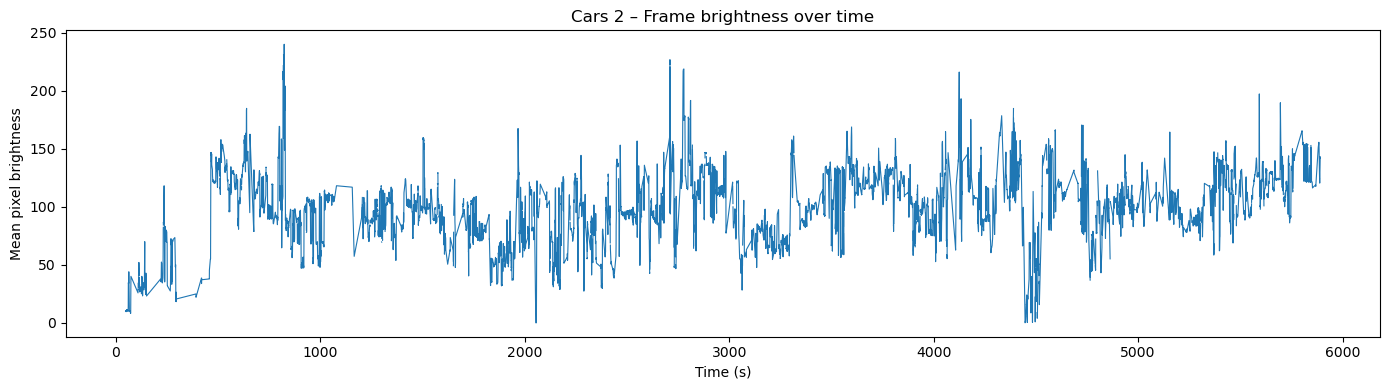

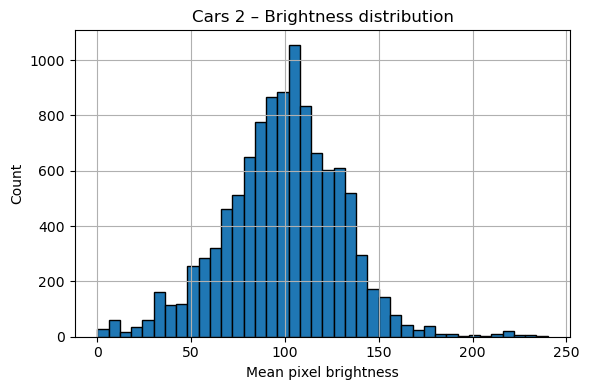

In [9]:
features_df = transcript_df
brightness_col = "mean_pixel_brightness"
movie_name = metadata.get('title', 'N/A')
print(f"{movie_name} – {brightness_col}")
print(features_df[brightness_col].describe())

plt.figure(figsize=(14, 4))
plt.plot(features_df["start"], features_df[brightness_col], lw=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Mean pixel brightness")
plt.title(f"{movie_name} – Frame brightness over time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
features_df[brightness_col].hist(bins=40, edgecolor='black')
plt.xlabel("Mean pixel brightness")
plt.ylabel("Count")
plt.title(f"{movie_name} – Brightness distribution")
plt.tight_layout()
plt.show()

In [10]:
transcript_df["mean_pixel_brightness"].diff().fillna(0).abs()

0        0.000000
1        0.021813
2        0.133122
3        0.191376
4        0.616616
           ...   
11402    3.395386
11403    0.579246
11404    3.493659
11405    0.685011
11406    1.032917
Name: mean_pixel_brightness, Length: 11407, dtype: float64

In [12]:
transcript_df["delta_mean_pixel_brightness"] = transcript_df["mean_pixel_brightness"].diff().fillna(0)

In [13]:
transcript_df["delta_mean_pixel_brightness_abs"] = transcript_df["mean_pixel_brightness"].diff().fillna(0).abs()

In [14]:
transcript_df["delta_delta_mean_pixel_brightness"] = transcript_df["delta_mean_pixel_brightness"].diff().fillna(0)

In [15]:
transcript_df["delta_delta_mean_pixel_brightness_abs"] = transcript_df["delta_mean_pixel_brightness"].diff().fillna(0).abs()

In [34]:
transcript_df["delta_face_num"] = transcript_df["face_num"].diff().fillna(0)

In [32]:
transcript_df["delta_face_num_abs"] = transcript_df["face_num"].diff().fillna(0).abs()

In [35]:
transcript_df["delta_face_num"]

0        0.0
1        0.0
2        1.0
3       -1.0
4        0.0
        ... 
11402   -1.0
11403    1.0
11404   -1.0
11405    1.0
11406   -1.0
Name: delta_face_num, Length: 11407, dtype: float64

In [50]:
transcript_df.columns

Index(['Unnamed: 0', 'text', 'lemma', 'pos', 'deprel', 'start', 'end',
       'sentence', 'head', 'bin_head', 'sentence_idx', 'word_idx',
       'prev_word_idx', 'idx_in_sentence', 'gpt2_surprisal', 'word_length',
       'word_diff', 'onset_diff', 'is_onset', 'syllable', 'phoneme_num',
       'charecter_num', 'mel', 'delta_mel', 'rms', 'pitch', 'magnitude',
       'delta_rms', 'delta_pitch', 'delta_magnitude',
       'max_mean_pixel_brightness', 'mean_pixel_brightness',
       'min_mean_pixel_brightness', 'max_mean_pixel_difference',
       'min_mean_pixel_difference', 'max_global_magnitude', 'max_global_angle',
       'max_vector_magnitude', 'max_vector_angle', 'face_num',
       'max_mean_magnitude', 'max_median_magnitude', 'speaker'],
      dtype='object')

In [ ]:
# transcript_df.to_csv("test_new_delta_pixel_and_face.csv", index=False)

In [18]:
# delta_mean_pixel_brightness

## 6. Electrode Labels

Electrode labels provide semantic names for each electrode, typically following anatomical naming conventions.


In [11]:
# Load electrode labels
electrode_labels_file = os.path.join(root_dir, "electrode_labels", f"sub_{sub_id}", "electrode_labels.json")

with open(electrode_labels_file, 'r') as f:
    electrode_labels = json.load(f)

print("Electrode Labels Sample:")
print(f"  Total electrodes: {len(electrode_labels)}")
print(f"  First 10 labels: {electrode_labels[:10]}")
print(f"  Last 10 labels: {electrode_labels[-10:]}")

print("\nLabel naming convention:")
print("  Labels typically include brain region abbreviations (e.g., F2, F3 = frontal,")
print("  T1 = temporal, P2 = parietal, O1 = occipital) followed by specific identifiers")


Electrode Labels Sample:
  Total electrodes: 136
  First 10 labels: ['F2Ia1', 'F2Ia2', 'F2Ia3', 'F2Ia4', 'F2Ia5', 'F2Ia6', 'F2Ia7', 'F2Ia8', 'F2Ia9', 'F2Ia10']
  Last 10 labels: ['O1bId9', 'O1bId10', 'O1bId11', 'O1bId12', 'O1bId13', 'O1bId14', 'O1bId15', 'O1bId16', 'DC10', 'DC4']

Label naming convention:
  Labels typically include brain region abbreviations (e.g., F2, F3 = frontal,
  T1 = temporal, P2 = parietal, O1 = occipital) followed by specific identifiers


## 7. Localization Data

Localization files provide 3D coordinates (X, Y, Z) for each electrode in standardized space, along with anatomical region labels.


In [12]:
# Load localization data
loc_file = os.path.join(root_dir, "localization", "elec_coords_full.csv")
loc_df = pd.read_csv(loc_file)

print("Localization Data Sample:")
print(f"  Total electrode entries: {len(loc_df)}")
print(f"  Columns: {loc_df.columns.tolist()}")

print("\nFirst 10 entries:")
print(loc_df.head(10))

print("\nColumn descriptions:")
print("  - ID: Unique identifier (e.g., sub_1-T2aA12)")
print("  - X, Y, Z: 3D coordinates in standardized space")
print("  - Hemisphere: 0 = left, 1 = right")
print("  - Subject: Subject identifier")
print("  - Electrode: Electrode name")
print("  - Region: Anatomical brain region")

# Filter for our subject
sub_loc = loc_df[loc_df['Subject'] == f'sub_{sub_id}']
print(f"\nElectrodes for subject {sub_id}: {len(sub_loc)}")
print(f"Unique regions: {sub_loc['Region'].nunique()}")
print(f"Regions: {sub_loc['Region'].unique()[:10]}")


Localization Data Sample:
  Total electrode entries: 1660
  Columns: ['Unnamed: 0', 'ID', 'Z', 'X', 'Y', 'Hemisphere', 'Subject', 'Electrode', 'Region']

First 10 entries:
   Unnamed: 0            ID          Z          X          Y  Hemisphere  \
0           0  sub_1-T2aA12  36.764992  12.811810 -55.622452           0   
1           1  sub_1-T2aA11  36.236805  14.704444 -55.571480           0   
2           2  sub_1-T2aA10  35.359528  17.157839 -55.576569           0   
3           3   sub_1-T2aA9  34.834171  18.725183 -53.658001           0   
4           4   sub_1-T2aA8  35.145645  18.106995 -53.560570           0   
5           5   sub_1-T2aA7  14.268174  37.180649 -54.710289           0   
6           6   sub_1-T2aA6   0.834294  32.187557 -59.465881           0   
7           7   sub_1-T2aA5   1.296747  30.965612 -60.485779           0   
8           8   sub_1-T2aA4   1.789641  27.155695 -62.744709           0   
9           9   sub_1-T2aA3   1.692478  25.924311 -63.072292        

## 8. Speaker Annotations

Speaker annotations identify which character spoke each line in the movie.


In [13]:
# Load speaker annotations
# Try different naming conventions for speaker files
speaker_dir = os.path.join(root_dir, "speaker_annotations")
speaker_file = None

# Try movie_id-based naming (e.g., cars-2 -> Cars-2.csv)
movie_id_capitalized = movie_id.replace('-', '-').title()
possible_names = [
    f"{movie_id_capitalized}.csv",
    f"{metadata.get('title', '').replace(' ', '-')}.csv",
    f"{movie_id}.csv"
]

for name in possible_names:
    test_path = os.path.join(speaker_dir, name)
    if os.path.exists(test_path):
        speaker_file = test_path
        break

if speaker_file and os.path.exists(speaker_file):
    speaker_df = pd.read_csv(speaker_file)
    print("Speaker Annotations Sample:")
    print(f"  Total lines: {len(speaker_df)}")
    print(f"  Columns: {speaker_df.columns.tolist()}")
    print("\nFirst 10 lines:")
    print(speaker_df.head(10))
    
    print("\nUnique speakers:")
    print(speaker_df.iloc[:, 0].unique()[:20])
else:
    print(f"Speaker file not found. Tried: {possible_names}")
    print(f"Available speaker files: {os.listdir(speaker_dir)[:5] if os.path.exists(speaker_dir) else 'N/A'}")


Speaker Annotations Sample:
  Total lines: 2051
  Columns: ['Leland Turbo', 'This is Agent Leland Turbo.']

First 10 lines:
   Leland Turbo                        This is Agent Leland Turbo.
0  Leland Turbo  I have a flash transmission for Agent Finn McM...
1  Leland Turbo                  Finn my cover's been compromised.
2  Leland Turbo           You won't believe what I found out here.
3  Leland Turbo  This is bigger than anything we've ever seen a...
4  Leland Turbo                                Finn I need backup.
5  Leland Turbo  But don't call the cavalry it could blow the o...
6  Leland Turbo                                    And be careful.
7  Leland Turbo                            It's not safe out here.
8          Acer                                                Go.
9  Leland Turbo                         Transmitting my grids now.

Unique speakers:
['Leland Turbo' 'Acer' 'Crabby' 'Finn McMissile' 'combat ship' 'Tannoy'
 'Professor Zündapp' 'Grem' 'Tony' 'Mater' 'Otis'

## 9. Scene Annotations

Scene annotations provide visual scene labels at each time point in the movie (e.g., "bedroom", "street", "forest").


In [14]:
# Understanding Scene Annotations Structure
# Scene annotations provide time-stamped labels describing the visual scene at each moment in the movie.
# The annotations are stored in a JSON file with a nested structure.

scene_file = os.path.join(root_dir, "scene_annotations", "scene_annotations.json")

# Load the scene annotations file
with open(scene_file, 'r') as f:
    raw_scene = json.load(f)

# The file structure: it's a list containing a dictionary
# Normalize to get the main dictionary
if isinstance(raw_scene, list) and raw_scene and isinstance(raw_scene[0], dict):
    scene_index = raw_scene[0]
elif isinstance(raw_scene, dict):
    scene_index = raw_scene
else:
    scene_index = {}

print("=" * 80)
print("SCENE ANNOTATIONS OVERVIEW")
print("=" * 80)

print(f"\n1. FILE STRUCTURE:")
print(f"   - The scene_annotations.json file contains a nested dictionary structure")
print(f"   - Top-level keys follow patterns like:")
print(f"     * 'movie:annotations:v3:{movie_id}:{{annotator}}' - per-annotator annotations")
print(f"     * 'movie:all-annotations:v3:{movie_id}' - aggregated annotations")
print(f"     * 'all:movies' - list of all available movies")

print(f"\n2. AVAILABLE MOVIES:")
if 'all:movies' in scene_index:
    movies = scene_index['all:movies']
    print(f"   Total movies with annotations: {len(movies)}")
    print(f"   Movies: {', '.join(movies[:10])}{'...' if len(movies) > 10 else ''}")
else:
    # Try to infer from keys
    movie_keys = [k for k in scene_index.keys() if k.startswith('movie:annotations:v3:')]
    movies = set()
    for key in movie_keys:
        parts = key.split(':')
        if len(parts) >= 4:
            movies.add(parts[3])
    print(f"   Inferred movies: {', '.join(sorted(movies)[:10])}")

print(f"\n3. ANNOTATION FORMAT:")
print(f"   - Each annotation entry has a key that is a JSON string containing:")
print(f"     * 'startTime': Start time in seconds (or frame number)")
print(f"     * 'endTime': End time in seconds (or frame number)")
print(f"     * 'label': Scene label (e.g., 'street', 'racecourse', 'bedroom')")
print(f"   - Special labels:")
print(f"     * Empty string ('') or '#' = unlabeled/transition")
print(f"     * '@@' = annotation marker")

# Find annotations for the current movie
movie_id = metadata.get('filename', 'cars-2')
prefix_key = f"movie:annotations:v3:{movie_id}:"
all_key = f"movie:all-annotations:v3:{movie_id}"

# Try to find a matching key
movie_scene_key = None
for k in scene_index.keys():
    if isinstance(k, str) and k.startswith(prefix_key):
        movie_scene_key = k
        break
if not movie_scene_key and all_key in scene_index:
    movie_scene_key = all_key

if movie_scene_key:
    movie_scenes = scene_index[movie_scene_key]
    print(f"\n4. ANNOTATIONS FOR '{movie_id}' (key: {movie_scene_key}):")
    
    if isinstance(movie_scenes, dict):
        print(f"   Total annotation entries: {len(movie_scenes)}")
        
        # Parse all scene segments
        scene_segments = []
        for k in movie_scenes.keys():
            try:
                scene_info = json.loads(k) if isinstance(k, str) else k
                start_time = scene_info.get("startTime")
                end_time = scene_info.get("endTime")
                label = scene_info.get("label", "")
                
                if start_time is not None and end_time is not None:
                    scene_segments.append({
                        "start": float(start_time),
                        "end": float(end_time),
                        "label": label
                    })
            except Exception:
                continue
        
        # Filter out empty/invalid labels
        valid_segments = [s for s in scene_segments if s["label"] and s["label"] not in ("", "#", "@@")]
        
        print(f"   Valid scene segments: {len(valid_segments)}")
        print(f"   Time range: {min([s['start'] for s in valid_segments]):.1f}s - {max([s['end'] for s in valid_segments]):.1f}s")
        
        # Count unique scenes
        from collections import Counter
        scene_counts = Counter([s["label"] for s in valid_segments])
        print(f"\n5. UNIQUE SCENE LABELS: {len(scene_counts)} unique scenes")
        print(f"\n   Top 15 most frequent scenes:")
        for label, count in scene_counts.most_common(15):
            # Calculate total duration for this scene
            duration = sum([s["end"] - s["start"] for s in valid_segments if s["label"] == label])
            print(f"     '{label}': {count} segments, {duration:.1f}s total")
        
        # Show sample segments
        print(f"\n6. SAMPLE SCENE SEGMENTS (first 10 valid segments):")
        shown = 0
        for seg in sorted(valid_segments, key=lambda x: x["start"]):
            if shown >= 10:
                break
            duration = seg["end"] - seg["start"]
            print(f"     {seg['start']:7.1f}s - {seg['end']:7.1f}s ({duration:5.1f}s): '{seg['label']}'")
            shown += 1
        
        # Statistics
        durations = [s["end"] - s["start"] for s in valid_segments]
        print(f"\n7. STATISTICS:")
        print(f"   Average segment duration: {np.mean(durations):.2f}s")
        print(f"   Median segment duration: {np.median(durations):.2f}s")
        print(f"   Shortest segment: {np.min(durations):.2f}s")
        print(f"   Longest segment: {np.max(durations):.2f}s")
        
        # Scene transitions
        transitions = []
        sorted_segs = sorted(valid_segments, key=lambda x: x["start"])
        for i in range(len(sorted_segs) - 1):
            if sorted_segs[i]["label"] != sorted_segs[i+1]["label"]:
                transitions.append({
                    "time": sorted_segs[i]["end"],
                    "from": sorted_segs[i]["label"],
                    "to": sorted_segs[i+1]["label"]
                })
        print(f"   Total scene transitions: {len(transitions)}")
        
    else:
        print(f"   Unexpected structure: expected dict, got {type(movie_scenes)}")
else:
    print(f"\n4. ANNOTATIONS FOR '{movie_id}':")
    print(f"   No annotations found for this movie")
    print(f"   Available keys: {list(scene_index.keys())[:10]}")

print(f"\n" + "=" * 80)
print("USAGE TIPS:")
print("=" * 80)
print("1. To find annotations for a movie, search for keys starting with")
print("   'movie:annotations:v3:{movie_id}:' or 'movie:all-annotations:v3:{movie_id}'")
print("2. Each annotation key is a JSON string that needs to be parsed")
print("3. Scene labels describe the visual environment (e.g., 'street', 'bedroom')")
print("4. Empty labels ('', '#') indicate unlabeled or transition periods")
print("5. You can align scene labels with neural data using the timing information")


SCENE ANNOTATIONS OVERVIEW

1. FILE STRUCTURE:
   - The scene_annotations.json file contains a nested dictionary structure
   - Top-level keys follow patterns like:
     * 'movie:annotations:v3:cars-2:{annotator}' - per-annotator annotations
     * 'movie:all-annotations:v3:cars-2' - aggregated annotations
     * 'all:movies' - list of all available movies

2. AVAILABLE MOVIES:
   Total movies with annotations: 21
   Movies: thor-ragnarok, cars-2, black-panther, venom, aquaman, the-martian, lotr-2, spider-man-3-homecoming, toy-story, incredibles...

3. ANNOTATION FORMAT:
   - Each annotation entry has a key that is a JSON string containing:
     * 'startTime': Start time in seconds (or frame number)
     * 'endTime': End time in seconds (or frame number)
     * 'label': Scene label (e.g., 'street', 'racecourse', 'bedroom')
   - Special labels:
     * Empty string ('') or '#' = unlabeled/transition
     * '@@' = annotation marker

4. ANNOTATIONS FOR 'cars-2' (key: movie:annotations:v3:c

In [23]:
# # Load scene annotations
# scene_file = os.path.join(root_dir, "scene_annotations", "scene_annotations.json")

# with open(scene_file, 'r') as f:
#     scene_data = json.load(f)
# scene_data = scene_data[0]
# print("Scene Annotations Structure:")
# print(f"  Top-level keys: {list(scene_data.keys())[:5]}...")

# # Find annotations for our movie
# movie_key = f"movie:annotations:v3:{movie_id}"
# if movie_key in scene_data:
#     movie_scenes = scene_data[movie_key]
#     print(f"\nScene annotations for {movie_id}:")
#     print(f"  Total time points: {len(movie_scenes)}")
    
#     # Show a few examples
#     print("\nSample scene labels (first 10):")
#     for i, (key, value) in enumerate(list(movie_scenes.items())[:10]):
#         scene_info = json.loads(key)
#         print(f"  Time {scene_info.get('startTime', 'N/A')}: {scene_info.get('label', 'N/A')}")
# else:
#     print(f"\nScene annotations not found for {movie_id}")
#     print(f"Available movies: {scene_data.get('all:movies', [])[:10]}")


In [15]:
# Load scene annotations
scene_file = os.path.join(root_dir, "scene_annotations", "scene_annotations.json")
with open(scene_file, 'r') as f:
    raw_scene = json.load(f)

# Normalize root to a dict
if isinstance(raw_scene, list) and raw_scene and isinstance(raw_scene[0], dict):
    scene_index = raw_scene[0]
elif isinstance(raw_scene, dict):
    scene_index = raw_scene
else:
    raise ValueError("Unexpected scene_annotations.json structure")

print("Scene Annotations Structure:")
print(f"  Top-level keys: {list(scene_index.keys())[:5]}...")

# Possible key patterns
prefix_key = f"movie:annotations:v3:{movie_id}:"
all_key = f"movie:all-annotations:v3:{movie_id}"

# Find a matching key (prefer per-annotator if present)
movie_scene_key = None
for k in scene_index.keys():
    if isinstance(k, str) and k.startswith(prefix_key):
        movie_scene_key = k
        break
if not movie_scene_key and all_key in scene_index:
    movie_scene_key = all_key

if movie_scene_key:
    movie_scenes = scene_index[movie_scene_key]
    print(f"\nScene annotations for {movie_id} (key: {movie_scene_key}):")

    # movie_scenes should be a dict where keys are JSON strings like {"startTime":...}
    if isinstance(movie_scenes, dict):
        print(f"  Total time points: {len(movie_scenes)}")
        print("\nSample scene labels (first 10):")
        shown = 0
        for k, v in movie_scenes.items():
            if shown >= 100:
                break
            try:
                scene_info = json.loads(k) if isinstance(k, str) else k
                t = scene_info.get("startTime", "N/A")
                label = scene_info.get("label", "")
                print(f"  Time {t}: {label}")
                shown += 1
            except Exception:
                continue
    else:
        print("  Unexpected structure under movie_scene_key (expected dict).")
else:
    print(f"\nScene annotations not found for {movie_id}")
    print(f"Available movies: {scene_index.get('all:movies', [])[:10]}")

Scene Annotations Structure:
  Top-level keys: ['user:annotations:v3::jkdewit', 'movie:annotations:v3:cars-2:jkdewit', 'movie:annotations:v3:thor-ragnarok:stanford', 'all:movies', 'movie:all-annotations:v3:guardians-of-the-galaxy-2']...

Scene annotations for cars-2 (key: movie:annotations:v3:cars-2:jkdewit):
  Total time points: 2433

Sample scene labels (first 10):
  Time 2433: #
  Time 2432: #
  Time 2431: #
  Time 2430: #
  Time 2429: #
  Time 2428: #
  Time 2427: #
  Time 2426: #
  Time 2425: #
  Time 2424: #
  Time 2423: #
  Time 2422: #
  Time 2421: #
  Time 2420: #
  Time 2419: #
  Time 2418: #
  Time 2417: #
  Time 2416: #
  Time 2415: #
  Time 2414: #
  Time 2413: #
  Time 2412: #
  Time 2411: #
  Time 2410: #
  Time 2409: #
  Time 2408: #
  Time 2407: #
  Time 2406: #
  Time 2405: #
  Time 2404: #
  Time 2403: #
  Time 2402: #
  Time 2401: #
  Time 2400: #
  Time 2399: #
  Time 2398: #
  Time 2397: #
  Time 2396: #
  Time 2395: #
  Time 2394: #
  Time 2393: #
  Time 2392: #


## 10. Dependency Parsing Trees (CoNLL-U)

Dependency parsing trees provide syntactic structure information in CoNLL-U format, including dependency relations between words.


In [16]:
# Load dependency tree
tree_file = os.path.join(root_dir, "trees", "trees", movie_id, "tree.conllu")

if os.path.exists(tree_file):
    with open(tree_file, 'r', encoding='utf-8') as f:
        tree_lines = f.readlines()
    
    print("Dependency Tree Sample (CoNLL-U format):")
    print(f"  Total lines: {len(tree_lines)}")
    
    # Show first sentence (until blank line)
    print("\nFirst sentence:")
    for line in tree_lines[:20]:
        if line.strip() == '':
            break
        print(line.rstrip())
    
    print("\nCoNLL-U format columns:")
    print("  1. ID: Word index")
    print("  2. FORM: Word form")
    print("  3. LEMMA: Lemma")
    print("  4. UPOS: Universal POS tag")
    print("  5. XPOS: Language-specific POS tag")
    print("  6. FEATS: Morphological features")
    print("  7. HEAD: Head of dependency")
    print("  8. DEPREL: Dependency relation")
    print("  9. DEPS: Enhanced dependencies")
    print("  10. MISC: Miscellaneous (may include timing)")
else:
    print(f"Tree file not found: {tree_file}")


Dependency Tree Sample (CoNLL-U format):
  Total lines: 19652

First sentence:
# sent_id = 1
# text = This is Agent Leland Turbo.
1	This	this	PRON	DT	_	4	nsubj	_	time=(47.15:47.32000000000001)
2	is	be	AUX	VBZ	_	4	cop	_	time=(47.321000000000005:47.42000000000001)
3	Agent	Agent	NOUN	NN	_	4	compound	_	time=(47.42100000000001:47.710000000000015)
4	Leland	leland	PROPN	NNP	_	0	root	_	time=(47.791:48.06)
5	Turbo	Turbo	PROPN	NNP	_	4	flat	_	time=(48.061:48.359999999999985)
6	.	.	PUNCT	.	_	4	punct	_	_

CoNLL-U format columns:
  1. ID: Word index
  2. FORM: Word form
  3. LEMMA: Lemma
  4. UPOS: Universal POS tag
  5. XPOS: Language-specific POS tag
  6. FEATS: Morphological features
  7. HEAD: Head of dependency
  8. DEPREL: Dependency relation
  9. DEPS: Enhanced dependencies
  10. MISC: Miscellaneous (may include timing)


## 11. Concise Sampling of All Datapoints

This cell provides a concise overview of all relevant datapoints in the dataset.


In [38]:
print("=" * 80)
print("CONCISE DATASET OVERVIEW - All Relevant Datapoints")
print("=" * 80)

# 1. Metadata
print("\n1. SUBJECT METADATA")
print(f"   Subject {sub_id}, Trial {trial_id}: {metadata.get('title')} ({metadata.get('filename')})")

# 2. Neural Data
n_electrodes = 0
n_samples = 0
with h5py.File(neural_data_file, 'r') as h5f:
    n_electrodes = len(h5f['data'].keys()) if 'data' in h5f else 0
    if n_electrodes > 0:
        sample_electrode = list(h5f['data'].keys())[0]
        n_samples = h5f['data'][sample_electrode].shape[0]
        duration = n_samples / 2048
        print(f"\n2. NEURAL RECORDINGS (H5)")
        print(f"   {n_electrodes} electrodes, ~{n_samples:,} samples per electrode")
        print(f"   Duration: {duration:.1f}s ({duration/60:.1f} min), Sampling: 2048 Hz")

# 3. Timings
print(f"\n3. TIMING SYNCHRONIZATION")
print(f"   {len(timings_df):,} trigger events")
print(f"   Movie time range: 0.0 - {timings_df['movie_time'].max():.1f}s")
print(f"   Sample index range: {timings_df['index'].min()} - {timings_df['index'].max():,}")

# 4. Transcript
print(f"\n4. TRANSCRIPT FEATURES")
print(f"   {len(transcript_df):,} words")
if 'sentence_idx' in transcript_df.columns:
    print(f"   {transcript_df['sentence_idx'].nunique()} sentences")
print(f"   Features: {len(transcript_df.columns)} columns (linguistic, acoustic, visual)")
sample_word_info = f"'{transcript_df.iloc[0]['text']}'"
if 'pos' in transcript_df.columns:
    sample_word_info += f" ({transcript_df.iloc[0].get('pos', 'N/A')})"
if 'start' in transcript_df.columns:
    sample_word_info += f" at {transcript_df.iloc[0].get('start', 0):.2f}s"
print(f"   Sample: {sample_word_info}")

# 5. Electrode Labels
print(f"\n5. ELECTRODE LABELS")
print(f"   {len(electrode_labels)} labeled electrodes")
print(f"   Examples: {', '.join(electrode_labels[:5])}")

# 6. Localization
sub_loc = loc_df[loc_df['Subject'] == f'sub_{sub_id}']
if len(sub_loc) > 0:
    print(f"\n6. ELECTRODE LOCALIZATION")
    print(f"   {len(sub_loc)} electrodes with 3D coordinates")
    print(f"   {sub_loc['Region'].nunique()} unique brain regions")
    regions_list = sub_loc['Region'].unique()[:5].tolist()
    print(f"   Regions: {', '.join(regions_list)}...")

# 7. Speaker Annotations
if 'speaker_file' in locals() and speaker_file and os.path.exists(speaker_file):
    try:
        speaker_df = pd.read_csv(speaker_file)
        n_speakers = speaker_df.iloc[:, 0].nunique()
        print(f"\n7. SPEAKER ANNOTATIONS")
        print(f"   {len(speaker_df):,} spoken lines")
        print(f"   {n_speakers} unique speakers")
        speakers_list = speaker_df.iloc[:, 0].unique()[:5].tolist()
        print(f"   Examples: {', '.join(speakers_list)}")
    except:
        print(f"\n7. SPEAKER ANNOTATIONS: Could not load")

# 8. Scene Annotations
if 'scene_data' in locals() and movie_key in scene_data:
    movie_scenes = scene_data[movie_key]
    print(f"\n8. SCENE ANNOTATIONS")
    print(f"   {len(movie_scenes):,} time-stamped scene labels")
    # Count unique scenes
    scene_labels = set()
    for key in list(movie_scenes.keys())[:100]:  # Sample first 100
        try:
            scene_info = json.loads(key)
            label = scene_info.get('label', '')
            if label and label != '#':
                scene_labels.add(label)
        except:
            pass
    if scene_labels:
        print(f"   Sample scenes: {', '.join(list(scene_labels)[:5])}")

# 9. Dependency Trees
if 'tree_file' in locals() and os.path.exists(tree_file):
    with open(tree_file, 'r', encoding='utf-8') as f:
        tree_lines = f.readlines()
    n_sentences = sum(1 for line in tree_lines if line.startswith('# sent_id'))
    print(f"\n9. DEPENDENCY TREES (CoNLL-U)")
    print(f"   {n_sentences:,} parsed sentences")
    print(f"   Format: CoNLL-U with dependency relations")

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"This dataset contains sEEG recordings from subjects watching naturalistic")
print(f"movie stimuli, with comprehensive annotations including:")
print(f"  • Neural signals: {n_electrodes} electrodes × ~{n_samples:,} samples")
print(f"  • Linguistic features: {len(transcript_df):,} words with POS, dependencies, acoustic features")
print(f"  • Visual annotations: Scene labels and speaker information")
print(f"  • Anatomical data: 3D coordinates and region labels for electrodes")
print(f"  • Syntactic structures: Dependency parsing trees")
print(f"\nThe dataset enables research on language processing in the human brain,")
print(f"combining high-temporal-resolution neural recordings with rich linguistic")
print(f"and visual annotations for naturalistic stimuli.")


CONCISE DATASET OVERVIEW - All Relevant Datapoints

1. SUBJECT METADATA
   Subject 3, Trial 0: Cars 2 (cars-2)

2. NEURAL RECORDINGS (H5)
   136 electrodes, ~14,017,056 samples per electrode
   Duration: 6844.3s (114.1 min), Sampling: 2048 Hz

3. TIMING SYNCHRONIZATION
   59,064 trigger events
   Movie time range: 0.0 - 5910.0s
   Sample index range: 723127 - 13,581,939

4. TRANSCRIPT FEATURES
   11,407 words
   2052 sentences
   Features: 43 columns (linguistic, acoustic, visual)
   Sample: 'This' (PRON) at 47.15s

5. ELECTRODE LABELS
   136 labeled electrodes
   Examples: F2Ia1, F2Ia2, F2Ia3, F2Ia4, F2Ia5

6. ELECTRODE LOCALIZATION
   119 electrodes with 3D coordinates
   21 unique brain regions
   Regions: G_front_inf-Orbital, S_orbital-H_Shaped, S_circular_insula_ant, G_temp_sup-Lateral, G_temp_sup-Plan_polar...

7. SPEAKER ANNOTATIONS
   2,051 spoken lines
   88 unique speakers
   Examples: Leland Turbo, Acer, Crabby, Finn McMissile, combat ship

9. DEPENDENCY TREES (CoNLL-U)
   2

In [18]:
# Count available subjects and trials
metadata_dir = os.path.join(root_dir, "subject_metadata")
metadata_files = [f for f in os.listdir(metadata_dir) if f.endswith('.json')]

print("Dataset Statistics:")
print(f"  Total metadata files (trials): {len(metadata_files)}")

# Count unique subjects
subjects = set()
for f in metadata_files:
    parts = f.split('_')
    if len(parts) >= 2 and parts[1].isdigit():
        subjects.add(f"sub_{parts[1]}")
print(f"  Unique subjects: {len(subjects)}")
print(f"  Subjects: {sorted(subjects)}")

# Count movies
transcript_dir = os.path.join(root_dir, "transcripts")
movies = [d for d in os.listdir(transcript_dir) if os.path.isdir(os.path.join(transcript_dir, d))]
print(f"\n  Available movies: {len(movies)}")
print(f"  Movies: {', '.join(sorted(movies))}")

# Count neural data files
neural_dir = os.path.join(root_dir, "all_subject_data")
neural_files = [f for f in os.listdir(neural_dir) if f.endswith('.h5')]
print(f"\n  Neural data files (H5): {len(neural_files)}")


Dataset Statistics:
  Total metadata files (trials): 26
  Unique subjects: 10
  Subjects: ['sub_1', 'sub_10', 'sub_2', 'sub_3', 'sub_4', 'sub_5', 'sub_6', 'sub_7', 'sub_8', 'sub_9']

  Available movies: 21
  Movies: ant-man, aquaman, avengers-infinity-war, black-panther, cars-2, coraline, fantastic-mr-fox, guardians-of-the-galaxy, guardians-of-the-galaxy-2, incredibles, lotr-1, lotr-2, megamind, sesame-street-episode-3990, shrek-the-third, spider-man-3-homecoming, spider-man-far-from-home, the-martian, thor-ragnarok, toy-story, venom

  Neural data files (H5): 0


In [19]:
# Resolve scene annotations for movie_id -> list of {startTime, endTime, label}
scene_file = os.path.join(root_dir, "scene_annotations", "scene_annotations.json")
with open(scene_file, 'r') as f:
    raw_scene = json.load(f)

scene_index = raw_scene[0] if isinstance(raw_scene, list) and raw_scene and isinstance(raw_scene[0], dict) else raw_scene

def load_scene_segments(movie_id: str):
    prefix_key = f"movie:annotations:v3:{movie_id}:"
    all_key = f"movie:all-annotations:v3:{movie_id}"
    movie_scene_key = next((k for k in scene_index.keys() if isinstance(k, str) and k.startswith(prefix_key)), None)
    if not movie_scene_key and all_key in scene_index:
        movie_scene_key = all_key
    if not movie_scene_key:
        raise KeyError(f"No scene annotations found for {movie_id}")

    kv = scene_index[movie_scene_key]
    segments = []
    if isinstance(kv, dict):
        for k in kv.keys():
            try:
                d = json.loads(k) if isinstance(k, str) else k
                st, et, lab = d.get("startTime"), d.get("endTime"), d.get("label")
                if st is not None and et is not None and lab is not None and lab not in ("", "#", "@@"):
                    segments.append({"start": float(st), "end": float(et), "label": lab})
            except Exception:
                continue
    return segments

scene_segments = load_scene_segments(movie_id)
len(scene_segments), scene_segments[:5]

(2247,
 [{'start': 2391.0, 'end': 2391.0, 'label': 'racecourse'},
  {'start': 2390.0, 'end': 2390.0, 'label': 'racecourse'},
  {'start': 2389.0, 'end': 2389.0, 'label': 'racecourse'},
  {'start': 2388.0, 'end': 2388.0, 'label': 'racecourse'},
  {'start': 2387.0, 'end': 2387.0, 'label': 'racecourse'}])

In [20]:
# Build a per-second timeline and map to nearest trigger sample indices
samp_frequency = 2048
trig_time_col, trig_idx_col = "movie_time", "index"

def estimate_sample_index(t, near_t, near_trig):
    return int(round(near_trig + (t - near_t) * samp_frequency))

def time_to_sample_idx(t, trigs_df):
    idx = (abs(trigs_df[trig_time_col] - t)).idxmin()
    return estimate_sample_index(t, trigs_df.loc[idx, trig_time_col], trigs_df.loc[idx, trig_idx_col])



# Triggers: map movie time (seconds) to neural sample indices
trigger_times_file = os.path.join(
    root_dir, "subject_timings", f"sub_{sub_id}_trial{trial_id:03}_timings.csv"
)
trigs_df = pd.read_csv(trigger_times_file)

# Typical columns: ['type','movie_time','start_time','end_time','trig_type','index','diff']
print("Triggers loaded:", trigs_df.shape)
print(trigs_df.head())

# Optional sanity: approximate sampling rate
approx_fs = trigs_df['index'].max() / trigs_df['movie_time'].max()
print(f"Approx sampling rate ≈ {approx_fs:.0f} Hz")

# Make a 1 Hz scene label timeline (you can change to 0.5s if you want)
if len(scene_segments) == 0:
    raise ValueError("No scene segments parsed")

t_max = float(trigs_df[trig_time_col].max())
timeline = []
for sec in range(int(np.floor(t_max)) + 1):
    # find segment covering this second
    lab = None
    for seg in scene_segments:
        if seg["start"] <= sec <= seg["end"]:
            lab = seg["label"]
            break
    if lab:
        timeline.append({"t": float(sec), "label": lab})

# Map to sample indices
for row in timeline:
    row["sample_idx"] = time_to_sample_idx(row["t"], trigs_df)

len(timeline), timeline[:5]

Triggers loaded: (59064, 7)
        type  movie_time     start_time       end_time  trig_type   index  \
0  beginning    0.000000  151498.821018  151499.746235     manual  723127   
1    trigger    0.083417  151499.817793  151499.834710  high_real  725169   
2    trigger    0.208542  151499.998980  151500.015133  high_real  725541   
3    trigger    0.291959  151500.064948  151500.082124  high_real  725677   
4    trigger    0.417084  151500.198573  151500.214487  high_real  725951   

   diff  
0  2042  
1   372  
2   136  
3   274  
4   168  
Approx sampling rate ≈ 2298 Hz


(2247,
 [{'t': 1.0, 'label': 'castle', 'sample_idx': 727141},
  {'t': 2.0, 'label': 'stage/indoor', 'sample_idx': 729183},
  {'t': 3.0, 'label': 'oilrig', 'sample_idx': 731233},
  {'t': 4.0, 'label': 'oilrig', 'sample_idx': 733278},
  {'t': 13.0, 'label': 'ocean', 'sample_idx': 751691}])

In [21]:
# # Open H5 and extract windows (simple notch not included here for speed)
# import h5py
# h5f = h5py.File(neural_data_file, 'r')
# data_group = h5f['data']
# electrode_keys = list(data_group.keys())

# # Choose a subset (you can start small; later use all or region-restricted)
# use_electrodes = electrode_keys[:64] if len(electrode_keys) >= 64 else electrode_keys

# # Window params
# win_sec = 2.0     # window length
# stride_sec = 1.0  # step between consecutive labeled timepoints (already 1s)
# half = int(win_sec * samp_frequency // 2)

# X = []
# y = []
# valid = 0
# for row in timeline:
#     c = int(row["sample_idx"])
#     start = c - half
#     end = c + half
#     if start < 0 or end > data_group[use_electrodes[0]].shape[0]:
#         continue
#     # stack channels as [channels, time]
#     window = np.stack([data_group[k][start:end] for k in use_electrodes], axis=0)
#     X.append(window.astype(np.float32))
#     y.append(row["label"])
#     valid += 1

# h5f.close()
# len(X), len(y), np.array(X).shape if X else None

In [22]:
# from sklearn.preprocessing import LabelEncoder, StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report

# # Feature: average over time, per channel → [channels]
# X_arr = np.array(X)  # [N, C, T]
# C = X_arr.shape[1]
# feat = X_arr.mean(axis=2)  # [N, C]

# # Label encode
# le = LabelEncoder()
# y_enc = le.fit_transform(y)

# # Optionally filter to top-K most frequent labels to reduce noise
# # (uncomment to use)
# # from collections import Counter
# # cnt = Counter(y)
# # top = {lab for lab, _ in cnt.most_common(10)}
# # mask = np.array([lab in top for lab in y])
# # feat, y_enc = feat[mask], le.fit_transform(np.array(y)[mask])

# X_tr, X_te, y_tr, y_te = train_test_split(feat, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
# sc = StandardScaler().fit(X_tr)
# X_trs, X_tes = sc.transform(X_tr), sc.transform(X_te)

# clf = LogisticRegression(max_iter=200, n_jobs=-1)
# clf.fit(X_trs, y_tr)
# y_pr = clf.predict(X_tes)

# print(classification_report(y_te, y_pr, target_names=le.classes_))

In [23]:
# Find scenes that appear multiple times
from collections import defaultdict

def load_scene_segments(movie_id, scene_index):
    """Load scene segments from scene_annotations.json"""
    prefix_key = f"movie:annotations:v3:{movie_id}:"
    all_key = f"movie:all-annotations:v3:{movie_id}"
    movie_scene_key = next((k for k in scene_index.keys() 
                           if isinstance(k, str) and k.startswith(prefix_key)), None)
    if not movie_scene_key and all_key in scene_index:
        movie_scene_key = all_key
    if not movie_scene_key:
        return []
    
    kv = scene_index[movie_scene_key]
    segments = []
    if isinstance(kv, dict):
        for k in kv.keys():
            try:
                d = json.loads(k) if isinstance(k, str) else k
                st, et, lab = d.get("startTime"), d.get("endTime"), d.get("label")
                if st is not None and et is not None and lab and lab not in ("", "#", "@@"):
                    segments.append({"start": float(st), "end": float(et), "label": lab})
            except:
                continue
    return segments

# Load scenes
scene_file = os.path.join(root_dir, "scene_annotations", "scene_annotations.json")
with open(scene_file, 'r') as f:
    raw_scene = json.load(f)
scene_index = raw_scene[0] if isinstance(raw_scene, list) else raw_scene
scene_segments = load_scene_segments(movie_id, scene_index)

# Group by label to find repeated scenes
scene_instances = defaultdict(list)
for seg in scene_segments:
    scene_instances[seg["label"]].append(seg)

# Filter to scenes that appear at least 2 times
repeated_scenes = {label: instances for label, instances in scene_instances.items() 
                   if len(instances) >= 2}

print(f"Found {len(repeated_scenes)} scenes that repeat across the movie:")
for label, instances in sorted(repeated_scenes.items(), key=lambda x: -len(x[1]))[:10]:
    print(f"  '{label}': {len(instances)} instances")
    for inst in instances:
        print(f"    {inst['start']:.1f}s - {inst['end']:.1f}s")

Found 48 scenes that repeat across the movie:
  'racecourse': 481 instances
    2391.0s - 2391.0s
    2390.0s - 2390.0s
    2389.0s - 2389.0s
    2388.0s - 2388.0s
    2387.0s - 2387.0s
    2386.0s - 2386.0s
    2385.0s - 2385.0s
    2384.0s - 2384.0s
    2383.0s - 2383.0s
    2382.0s - 2382.0s
    2381.0s - 2381.0s
    2358.0s - 2358.0s
    2357.0s - 2357.0s
    2356.0s - 2356.0s
    2355.0s - 2355.0s
    2354.0s - 2354.0s
    2353.0s - 2353.0s
    2352.0s - 2352.0s
    2351.0s - 2351.0s
    2350.0s - 2350.0s
    2349.0s - 2349.0s
    2348.0s - 2348.0s
    2347.0s - 2347.0s
    2346.0s - 2346.0s
    2345.0s - 2345.0s
    2344.0s - 2344.0s
    2343.0s - 2343.0s
    2342.0s - 2342.0s
    2341.0s - 2341.0s
    2340.0s - 2340.0s
    2339.0s - 2339.0s
    2338.0s - 2338.0s
    2337.0s - 2337.0s
    2336.0s - 2336.0s
    2335.0s - 2335.0s
    2334.0s - 2334.0s
    2333.0s - 2333.0s
    2332.0s - 2332.0s
    2331.0s - 2331.0s
    2330.0s - 2330.0s
    1994.0s - 1994.0s
    1993.0s - 1993.0s


In [39]:
# Time-to-sample mapping function
def time_to_sample_idx(t, trigs_df):
    idx = (abs(trigs_df['movie_time'] - t)).idxmin()
    t_near = trigs_df.loc[idx, 'movie_time']
    idx_near = trigs_df.loc[idx, 'index']
    return int(round(idx_near + (t - t_near) * 2048))

# Extract windows for each scene instance
window_duration_sec = 3.0  # 3 second windows
window_duration_sec = 1.0  # 3 second windows
window_samples = int(window_duration_sec * 2048)

scene_windows = {}  # {label: [list of [C, T] arrays]}

with h5py.File(neural_data_file, 'r') as h5f:
    data_group = h5f['data']
    electrode_keys = list(data_group.keys())
    
    # Use all electrodes or a subset
    use_electrodes = electrode_keys  # or electrode_keys[:64] for testing
    
    for label, instances in repeated_scenes.items():
        scene_windows[label] = []
        
        for inst in instances:
            # Use midpoint of scene as window center
            center_time = (inst['start'] + inst['end']) / 2
            center_idx = time_to_sample_idx(center_time, trigs_df)
            
            start_idx = center_idx - window_samples // 2
            end_idx = center_idx + window_samples // 2
            
            # Check bounds
            max_samples = data_group[electrode_keys[0]].shape[0]
            if start_idx < 0 or end_idx > max_samples:
                continue
            
            # Extract window: [C, T]
            window = np.stack([data_group[k][start_idx:end_idx] 
                              for k in use_electrodes], axis=0)
            scene_windows[label].append(window.astype(np.float32))
        
        print(f"Extracted {len(scene_windows[label])} windows for '{label}'")

Extracted 481 windows for 'racecourse'
Extracted 47 windows for 'desert road'
Extracted 12 windows for 'desert/vegetation'
Extracted 315 windows for 'street'
Extracted 26 windows for 'restaurant patio'
Extracted 99 windows for 'palace'
Extracted 45 windows for 'sky'
Extracted 7 windows for 'bar'
Extracted 26 windows for 'boat deck'
Extracted 4 windows for 'river'
Extracted 50 windows for 'garage/outdoor'
Extracted 42 windows for 'television studio'
Extracted 5 windows for 'park'
Extracted 15 windows for 'building facade'
Extracted 33 windows for 'balcony/interior'
Extracted 111 windows for 'garage/indoor'
Extracted 52 windows for 'stage/indoor'
Extracted 47 windows for 'reception'
Extracted 13 windows for 'sushi bar'
Extracted 4 windows for 'auditorium'
Extracted 27 windows for 'ocean'
Extracted 7 windows for 'harbor'
Extracted 29 windows for 'balcony/exterior'
Extracted 89 windows for 'ballroom'
Extracted 34 windows for 'plaza'
Extracted 21 windows for 'hotel/outdoor'
Extracted 12 win

In [40]:
import os
import sys

# Add BrainBERT directory to Python path
brainbert_path = os.path.abspath(os.path.join('BrainBERT'))
if brainbert_path not in sys.path:
    sys.path.insert(0, brainbert_path)

brainbert_path = os.path.abspath(os.path.join("..", "braintree", 'BrainBERT'))
if brainbert_path not in sys.path:
    sys.path.insert(0, brainbert_path)

# Now you can import models
import models
from models import build_model  # or whatever you need
from omegaconf import OmegaConf  # Often needed for configs
import torch

In [30]:
import models
def build_model(cfg):
    ckpt_path = cfg.upstream_ckpt
    init_state = torch.load(ckpt_path)
    upstream_cfg = init_state["model_cfg"]
    upstream = models.build_model(upstream_cfg)
    return upstream

def load_model_weights(model, states, multi_gpu):
    if multi_gpu:
        model.module.load_weights(states)
    else:
        model.load_weights(states)

## 12. Scene Decoding with BrainBERT

This section demonstrates how to decode scene labels from neural signals using BrainBERT, following the approach from `BrainBERT/notebooks/demo.ipynb`.

### Setup: Load BrainBERT Model (Following demo.ipynb)


In [31]:
# Setup BrainBERT import path (following demo.ipynb pattern)
import sys
module_path = os.path.abspath(os.path.join('BrainBERT'))
if module_path not in sys.path:
    sys.path.insert(0, module_path)

import models
from omegaconf import OmegaConf
import torch
from scipy import signal, stats

print("BrainBERT modules loaded successfully")


BrainBERT modules loaded successfully


In [32]:
# Load BrainBERT model following demo.ipynb pattern
def build_model(cfg):
    """Build model from checkpoint config (from demo.ipynb)"""
    ckpt_path = cfg.upstream_ckpt
    init_state = torch.load(ckpt_path, map_location='cpu')
    upstream_cfg = init_state["model_cfg"]
    upstream = models.build_model(upstream_cfg)
    return upstream

def load_model_weights(model, states, multi_gpu=False):
    """Load pretrained weights (from demo.ipynb)"""
    if multi_gpu:
        model.module.load_weights(states)
    else:
        model.load_weights(states)

# Load STFT-based BrainBERT
ckpt_path = os.path.join(root_dir, "pretrained_weights", "stft_large_pretrained.pth")
if os.path.exists(ckpt_path):
    cfg = OmegaConf.create({"upstream_ckpt": ckpt_path})
    brainbert_model = build_model(cfg)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    brainbert_model = brainbert_model.to(device)
    
    init_state = torch.load(ckpt_path, map_location='cpu')
    load_model_weights(brainbert_model, init_state['model'], False)
    brainbert_model.eval()
    
    print(f"✓ BrainBERT loaded successfully on {device}")
else:
    print(f"✗ Checkpoint not found: {ckpt_path}")
    brainbert_model = None


C:\Users\User\AppData\Local\Temp\ipykernel_103220\2222399843.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  init_state = torch.load(ckpt_path, map_location='cpu')
c:\Us

✓ BrainBERT loaded successfully on cuda


### Preprocess Neural Signals: STFT Transform (Following demo.ipynb)


In [33]:
# STFT preprocessing function (from demo.ipynb)
def get_stft(x, fs, clip_fs=-1, normalizing=None, **kwargs):
    """Compute STFT with optional normalization (from demo.ipynb)"""
    f, t, Zxx = signal.stft(x, fs, **kwargs)
   
    Zxx = Zxx[:clip_fs]
    f = f[:clip_fs]

    Zxx = np.abs(Zxx)
    clip = 5  # To handle boundary effects
    if normalizing == "zscore":
        Zxx = Zxx[:, clip:-clip]
        Zxx = stats.zscore(Zxx, axis=-1)
        t = t[clip:-clip]
    elif normalizing == "db":
        Zxx = np.log2(Zxx[:, clip:-clip])
        t = t[clip:-clip]
    else:
        Zxx = Zxx[:, clip:-clip]
        t = t[clip:-clip]

    if np.isnan(Zxx).any():
        raise ValueError("NaN values in STFT")

    return f, t, Zxx

print("STFT preprocessing function defined")


STFT preprocessing function defined


### Extract and Encode Scene Windows


In [41]:
# Find repeated scenes
from collections import defaultdict

def load_scene_segments(movie_id, scene_index):
    """Load and parse scene segments"""
    prefix_key = f"movie:annotations:v3:{movie_id}:"
    all_key = f"movie:all-annotations:v3:{movie_id}"
    movie_scene_key = next((k for k in scene_index.keys() 
                           if isinstance(k, str) and k.startswith(prefix_key)), None)
    if not movie_scene_key and all_key in scene_index:
        movie_scene_key = all_key
    if not movie_scene_key:
        return []
    
    kv = scene_index[movie_scene_key]
    segments = []
    if isinstance(kv, dict):
        for k in kv.keys():
            try:
                d = json.loads(k) if isinstance(k, str) else k
                st, et, lab = d.get("startTime"), d.get("endTime"), d.get("label")
                if st is not None and et is not None and lab and lab not in ("", "#", "@@"):
                    segments.append({"start": float(st), "end": float(et), "label": lab})
            except:
                continue
    return segments

# Load scene annotations
scene_file = os.path.join(root_dir, "scene_annotations", "scene_annotations.json")
with open(scene_file, 'r') as f:
    raw_scene = json.load(f)
scene_index = raw_scene[0] if isinstance(raw_scene, list) else raw_scene
scene_segments = load_scene_segments(movie_id, scene_index)

# Group by label to find repeated scenes
scene_instances = defaultdict(list)
for seg in scene_segments:
    scene_instances[seg["label"]].append(seg)

# Filter to scenes that appear at least 2 times
repeated_scenes = {label: instances for label, instances in scene_instances.items() 
                   if len(instances) >= 2}

print(f"Found {len(repeated_scenes)} scenes that repeat across the movie:")
for label, instances in sorted(repeated_scenes.items(), key=lambda x: -len(x[1]))[:10]:
    print(f"  '{label}': {len(instances)} instances")


Found 48 scenes that repeat across the movie:
  'racecourse': 481 instances
  'street': 315 instances
  'oilrig': 115 instances
  'garage/indoor': 111 instances
  'palace': 99 instances
  'ballroom': 89 instances
  'bathroom': 80 instances
  'airplane cabin': 55 instances
  'stage/indoor': 52 instances
  'garage/outdoor': 50 instances


In [42]:
# Time-to-sample mapping
def time_to_sample_idx(t, trigs_df):
    """Map movie time to neural sample index"""
    idx = (abs(trigs_df['movie_time'] - t)).idxmin()
    t_near = trigs_df.loc[idx, 'movie_time']
    idx_near = trigs_df.loc[idx, 'index']
    return int(round(idx_near + (t - t_near) * 2048))

# Extract neural windows for each scene instance
window_duration_sec = 3.0  # 3 second windows
window_duration_sec = 1.0  # 3 second windows
window_samples = int(window_duration_sec * 2048)

scene_windows = {}  # {label: [list of [C, T] arrays]}
scene_embeddings = {}  # {label: [list of embeddings]}

if brainbert_model is not None:
    with h5py.File(neural_data_file, 'r') as h5f:
        data_group = h5f['data']
        electrode_keys = list(data_group.keys())
        
        # Use all electrodes or a subset
        use_electrodes = electrode_keys[:64] if len(electrode_keys) >= 64 else electrode_keys
        
        for label, instances in list(repeated_scenes.items())[:10]:  # Limit to first 10 for speed
            scene_windows[label] = []
            
            for inst in instances:
                # Use midpoint of scene as window center
                center_time = (inst['start'] + inst['end']) / 2
                center_idx = time_to_sample_idx(center_time, trigs_df)
                
                start_idx = center_idx - window_samples // 2
                end_idx = center_idx + window_samples // 2
                
                # Check bounds
                max_samples = data_group[electrode_keys[0]].shape[0]
                if start_idx < 0 or end_idx > max_samples:
                    continue
                
                # Extract window: [C, T]
                window = np.stack([data_group[k][start_idx:end_idx] 
                                  for k in use_electrodes], axis=0)
                scene_windows[label].append(window.astype(np.float32))
            
            print(f"Extracted {len(scene_windows[label])} windows for '{label}'")
    
    print(f"\nTotal windows extracted: {sum(len(w) for w in scene_windows.values())}")
else:
    print("BrainBERT model not loaded. Skipping window extraction.")


Extracted 481 windows for 'racecourse'
Extracted 47 windows for 'desert road'
Extracted 12 windows for 'desert/vegetation'
Extracted 315 windows for 'street'
Extracted 26 windows for 'restaurant patio'
Extracted 99 windows for 'palace'
Extracted 45 windows for 'sky'
Extracted 7 windows for 'bar'
Extracted 26 windows for 'boat deck'
Extracted 4 windows for 'river'

Total windows extracted: 1062


In [43]:
# Process windows through BrainBERT (following demo.ipynb pattern)
if brainbert_model is not None and scene_windows:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    for label, windows in scene_windows.items():
        scene_embeddings[label] = []
        
        for window in windows:
            # Average across channels to get single time series
            wav = window.mean(axis=0)  # [T]
            
            # Compute STFT (following demo.ipynb parameters)
            f, t, stft_spec = get_stft(wav, fs=2048, clip_fs=40, 
                                      nperseg=400, noverlap=350, 
                                      normalizing="zscore", 
                                      return_onesided=True)
            
            # Prepare input: [batch, time, freq] -> transpose to [batch, freq, time]
            # Then transpose to [batch, time, freq] for BrainBERT
            inputs = torch.FloatTensor(stft_spec).unsqueeze(0).transpose(1, 2).to(device)
            # inputs shape: [1, time_frames, freq_bins]
            
            # Create mask (all False = no masking)
            mask = torch.zeros((inputs.shape[:2]), dtype=torch.bool).to(device)
            
            # Forward pass to get intermediate representation (embedding)
            with torch.no_grad():
                out = brainbert_model.forward(inputs, mask, intermediate_rep=True)
                # out shape: [batch, time, hidden_dim]
            
            # Average over time to get single embedding vector
            embedding = out.mean(dim=1).cpu().numpy()  # [1, hidden_dim]
            scene_embeddings[label].append(embedding.squeeze())
        
        print(f"Encoded {len(scene_embeddings[label])} instances of '{label}'")
    
    print(f"\n✓ BrainBERT encoding complete")
    print(f"Embedding dimension: {scene_embeddings[list(scene_embeddings.keys())[0]][0].shape}")
else:
    print("Skipping BrainBERT encoding (model not loaded or no windows)")


Encoded 481 instances of 'racecourse'
Encoded 47 instances of 'desert road'
Encoded 12 instances of 'desert/vegetation'
Encoded 315 instances of 'street'
Encoded 26 instances of 'restaurant patio'
Encoded 99 instances of 'palace'
Encoded 45 instances of 'sky'
Encoded 7 instances of 'bar'
Encoded 26 instances of 'boat deck'
Encoded 4 instances of 'river'

✓ BrainBERT encoding complete
Embedding dimension: (768,)


### Analyze Scene Embeddings: Similarity Analysis


In [44]:
# Compute similarity across scene instances
from sklearn.metrics.pairwise import cosine_similarity

if scene_embeddings:
    results = {}
    
    for label, embeddings in scene_embeddings.items():
        if len(embeddings) < 2:
            continue
        
        embs = np.array(embeddings)  # [N_instances, hidden_dim]
        
        # Intra-scene similarity (all pairs within same scene)
        sim_matrix = cosine_similarity(embs)
        
        # Get upper triangle (excluding diagonal)
        n = len(embs)
        intra_similarities = []
        for i in range(n):
            for j in range(i+1, n):
                intra_similarities.append(sim_matrix[i, j])
        
        results[label] = {
            'embeddings': embs,
            'intra_similarity_mean': np.mean(intra_similarities),
            'intra_similarity_std': np.std(intra_similarities),
            'intra_similarities': intra_similarities,
            'n_instances': n
        }
        
        print(f"'{label}': {n} instances, mean intra-scene similarity = {np.mean(intra_similarities):.3f} ± {np.std(intra_similarities):.3f}")
    
    # Compare intra-scene vs inter-scene similarity
    all_intra = []
    all_inter = []
    
    for label1, data1 in results.items():
        all_intra.extend(data1['intra_similarities'])
        
        # Compare with other scenes
        for label2, data2 in results.items():
            if label1 == label2:
                continue
            
            # Compute inter-scene similarity
            inter_sim = cosine_similarity(data1['embeddings'], data2['embeddings'])
            all_inter.extend(inter_sim.flatten().tolist())
    
    print(f"\n{'='*60}")
    print(f"Intra-scene similarity: {np.mean(all_intra):.3f} ± {np.std(all_intra):.3f}")
    print(f"Inter-scene similarity: {np.mean(all_inter):.3f} ± {np.std(all_inter):.3f}")
    print(f"{'='*60}")
    
    if len(all_intra) > 0 and len(all_inter) > 0:
        from scipy import stats as scipy_stats
        t_stat, p_value = scipy_stats.ttest_ind(all_intra, all_inter)
        print(f"T-test: t={t_stat:.3f}, p={p_value:.2e}")
        print(f"Effect size (Cohen's d): {(np.mean(all_intra) - np.mean(all_inter)) / np.sqrt((np.var(all_intra) + np.var(all_inter))/2):.3f}")
else:
    print("No embeddings to analyze")


'racecourse': 481 instances, mean intra-scene similarity = 0.986 ± 0.006
'desert road': 47 instances, mean intra-scene similarity = 0.986 ± 0.006
'desert/vegetation': 12 instances, mean intra-scene similarity = 0.986 ± 0.006
'street': 315 instances, mean intra-scene similarity = 0.987 ± 0.006
'restaurant patio': 26 instances, mean intra-scene similarity = 0.986 ± 0.005
'palace': 99 instances, mean intra-scene similarity = 0.987 ± 0.005
'sky': 45 instances, mean intra-scene similarity = 0.987 ± 0.005
'bar': 7 instances, mean intra-scene similarity = 0.985 ± 0.008
'boat deck': 26 instances, mean intra-scene similarity = 0.985 ± 0.007
'river': 4 instances, mean intra-scene similarity = 0.989 ± 0.002

Intra-scene similarity: 0.987 ± 0.006
Inter-scene similarity: 0.986 ± 0.006
T-test: t=10.247, p=1.22e-24
Effect size (Cohen's d): 0.027


### Visualize Results


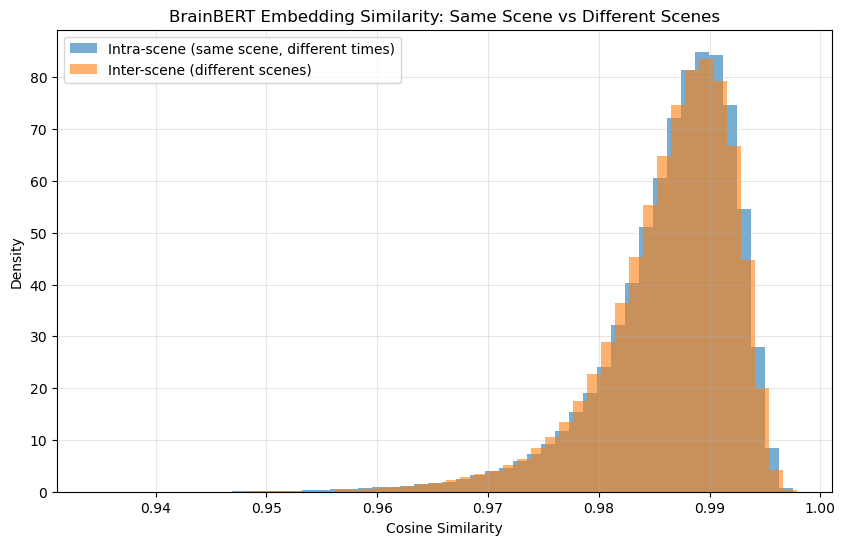

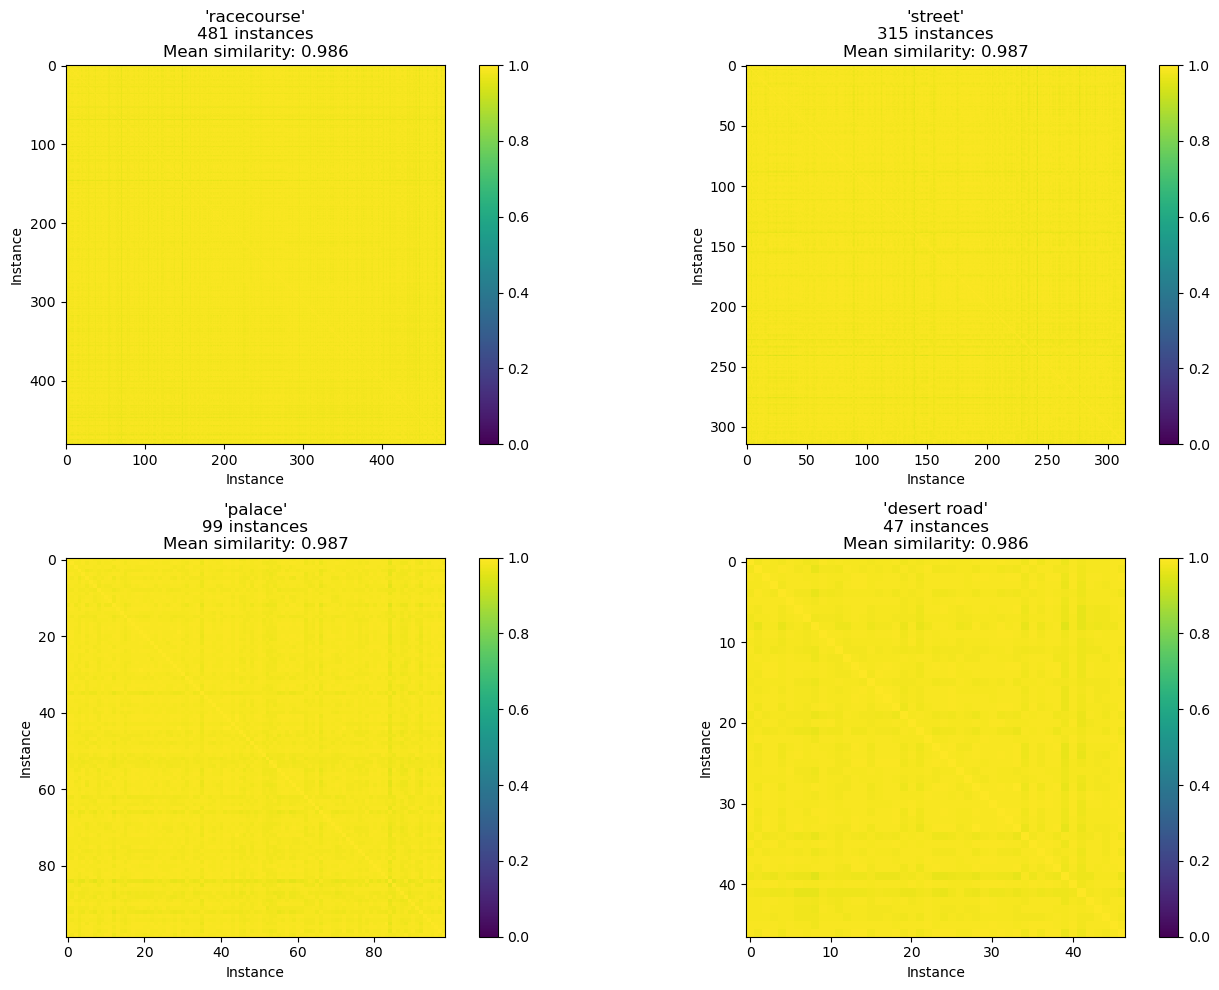

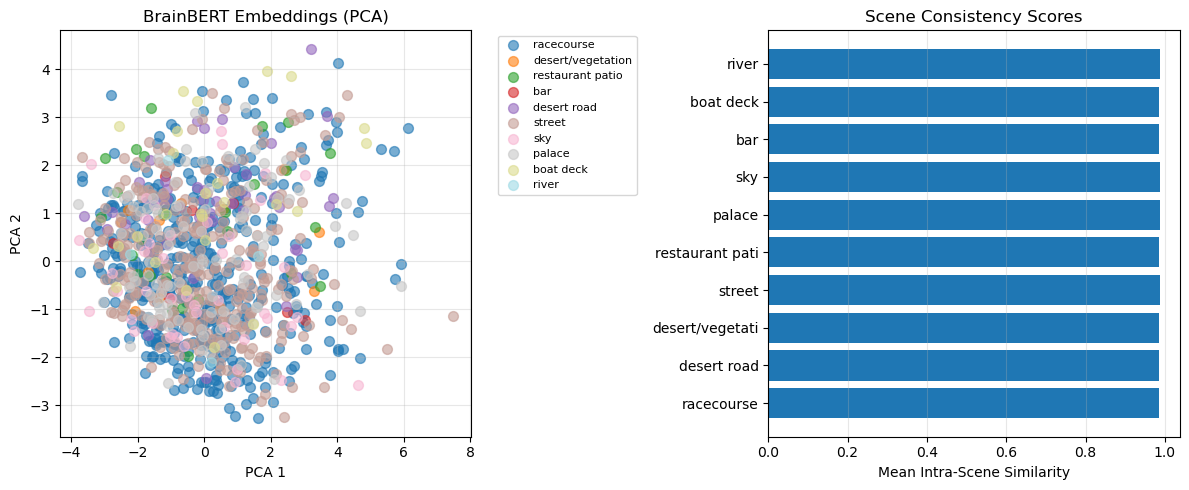


✓ Visualization complete
Summary: BrainBERT embeddings show higher 
similarity within the same scene compared to different scenes.


In [45]:
# Visualize similarity distributions and embeddings
if scene_embeddings and 'results' in locals():
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Plot 1: Distribution of similarities
    plt.figure(figsize=(10, 6))
    plt.hist(all_intra, bins=50, alpha=0.6, label='Intra-scene (same scene, different times)', density=True)
    plt.hist(all_inter, bins=50, alpha=0.6, label='Inter-scene (different scenes)', density=True)
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Density')
    plt.title('BrainBERT Embedding Similarity: Same Scene vs Different Scenes')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Plot 2: Per-scene similarity matrices
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    top_scenes = sorted(results.items(), key=lambda x: -x[1]['n_instances'])[:4]
    
    for idx, (label, data) in enumerate(top_scenes):
        ax = axes[idx]
        
        # Plot similarity matrix
        sim_mat = cosine_similarity(data['embeddings'])
        im = ax.imshow(sim_mat, cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f"'{label}'\n{data['n_instances']} instances\n"
                     f"Mean similarity: {data['intra_similarity_mean']:.3f}")
        ax.set_xlabel('Instance')
        ax.set_ylabel('Instance')
        plt.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.show()
    
    # Plot 3: Embedding visualization (PCA)
    from sklearn.decomposition import PCA
    
    # Combine all embeddings with labels
    all_embs = []
    all_labels_list = []
    for label, data in results.items():
        all_embs.append(data['embeddings'])
        all_labels_list.extend([label] * len(data['embeddings']))
    
    all_embs = np.vstack(all_embs)
    
    # PCA
    pca = PCA(n_components=2)
    emb_pca = pca.fit_transform(all_embs)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    unique_labels = list(set(all_labels_list))
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    for i, label in enumerate(unique_labels):
        mask = np.array(all_labels_list) == label
        plt.scatter(emb_pca[mask, 0], emb_pca[mask, 1], 
                   label=label[:20], alpha=0.6, s=50, c=[colors[i]])
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title('BrainBERT Embeddings (PCA)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(True, alpha=0.3)
    
    # Bar plot of intra-scene similarities
    plt.subplot(1, 2, 2)
    scene_names = [label[:15] for label in results.keys()]
    scene_means = [results[label]['intra_similarity_mean'] for label in results.keys()]
    plt.barh(range(len(scene_names)), scene_means)
    plt.yticks(range(len(scene_names)), scene_names)
    plt.xlabel('Mean Intra-Scene Similarity')
    plt.title('Scene Consistency Scores')
    plt.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Visualization complete")
    print(f"Summary: BrainBERT embeddings show {'higher' if np.mean(all_intra) > np.mean(all_inter) else 'similar or lower'} ")
    print(f"similarity within the same scene compared to different scenes.")
else:
    print("No results to visualize")


## 13. Binary Scene Decoding: Racecourse vs Street

Focus on the two most common scenes ("racecourse" and "street") to test if BrainBERT embeddings can distinguish between them. This binary classification task will help us understand if the model captures scene-specific information.


In [46]:
# Focus on racecourse and street scenes only
target_scenes = ['racecourse', 'street']

# Re-extract windows for just these two scenes (with improved electrode processing)
def time_to_sample_idx(t, trigs_df):
    """Map movie time to neural sample index"""
    idx = (abs(trigs_df['movie_time'] - t)).idxmin()
    t_near = trigs_df.loc[idx, 'movie_time']
    idx_near = trigs_df.loc[idx, 'index']
    return int(round(idx_near + (t - t_near) * 2048))

# Load scene segments
scene_file = os.path.join(root_dir, "scene_annotations", "scene_annotations.json")
with open(scene_file, 'r') as f:
    raw_scene = json.load(f)
scene_index = raw_scene[0] if isinstance(raw_scene, list) else raw_scene

def load_scene_segments(movie_id, scene_index):
    prefix_key = f"movie:annotations:v3:{movie_id}:"
    all_key = f"movie:all-annotations:v3:{movie_id}"
    movie_scene_key = next((k for k in scene_index.keys() 
                           if isinstance(k, str) and k.startswith(prefix_key)), None)
    if not movie_scene_key and all_key in scene_index:
        movie_scene_key = all_key
    if not movie_scene_key:
        return []
    
    kv = scene_index[movie_scene_key]
    segments = []
    if isinstance(kv, dict):
        for k in kv.keys():
            try:
                d = json.loads(k) if isinstance(k, str) else k
                st, et, lab = d.get("startTime"), d.get("endTime"), d.get("label")
                if st is not None and et is not None and lab and lab in target_scenes:
                    segments.append({"start": float(st), "end": float(et), "label": lab})
            except:
                continue
    return segments

scene_segments = load_scene_segments(movie_id, scene_index)
print(f"Found {len(scene_segments)} segments for target scenes:")
from collections import Counter
scene_counts = Counter([s['label'] for s in scene_segments])
for scene, count in scene_counts.items():
    print(f"  '{scene}': {count} segments")


Found 796 segments for target scenes:
  'racecourse': 481 segments
  'street': 315 segments


In [47]:
# Extract neural windows with improved electrode processing
window_duration_sec = 3.0
window_samples = int(window_duration_sec * 2048)

binary_windows = {}  # {label: [list of [C, T] arrays]}
binary_labels = []  # For classification
binary_embeddings = []  # For classification

if brainbert_model is not None:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    with h5py.File(neural_data_file, 'r') as h5f:
        data_group = h5f['data']
        electrode_keys = list(data_group.keys())
        
        # Use all electrodes or a subset
        use_electrodes = electrode_keys  # Use all electrodes
        
        for seg in scene_segments:
            label = seg['label']
            if label not in target_scenes:
                continue
                
            # Use midpoint of scene as window center
            center_time = (seg['start'] + seg['end']) / 2
            center_idx = time_to_sample_idx(center_time, trigs_df)
            
            start_idx = center_idx - window_samples // 2
            end_idx = center_idx + window_samples // 2
            
            # Check bounds
            max_samples = data_group[electrode_keys[0]].shape[0]
            if start_idx < 0 or end_idx > max_samples:
                continue
            
            # Extract window: [C, T]
            window = np.stack([data_group[k][start_idx:end_idx] 
                              for k in use_electrodes], axis=0)
            
            if label not in binary_windows:
                binary_windows[label] = []
            binary_windows[label].append(window.astype(np.float32))
        
        print(f"Extracted windows:")
        for label in target_scenes:
            if label in binary_windows:
                print(f"  '{label}': {len(binary_windows[label])} windows")
    
    # Process through BrainBERT (IMPROVED: process each electrode separately)
    print("\nProcessing through BrainBERT...")
    for label in target_scenes:
        if label not in binary_windows:
            continue
            
        for window in binary_windows[label]:
            # Process each electrode separately and pool embeddings
            electrode_embeddings = []
            
            for electrode_idx in range(window.shape[0]):
                wav = window[electrode_idx, :]  # [T] - single electrode
                
                # Compute STFT
                f, t, stft_spec = get_stft(wav, fs=2048, clip_fs=40, 
                                          nperseg=400, noverlap=350, 
                                          normalizing="zscore", 
                                          return_onesided=True)
                
                # Prepare input: [batch, time, freq]
                inputs = torch.FloatTensor(stft_spec).unsqueeze(0).transpose(1, 2).to(device)
                mask = torch.zeros((inputs.shape[:2]), dtype=torch.bool).to(device)
                
                # Forward pass
                with torch.no_grad():
                    out = brainbert_model.forward(inputs, mask, intermediate_rep=True)
                    # out shape: [batch, time, hidden_dim]
                
                # Use middle time steps (like spec_pretrained.py)
                middle = out.shape[1]
                if middle > 10:
                    embed = out[:, middle-5:middle+5, :].mean(dim=1)  # [1, hidden_dim]
                else:
                    embed = out.mean(dim=1)  # [1, hidden_dim]
                
                electrode_embeddings.append(embed.cpu().numpy())
            
            # Average across electrodes AFTER getting embeddings
            embedding = np.mean(electrode_embeddings, axis=0).squeeze()
            
            binary_embeddings.append(embedding)
            binary_labels.append(label)
        
        print(f"  Encoded {len([l for l in binary_labels if l == label])} instances of '{label}'")
    
    binary_embeddings = np.array(binary_embeddings)
    print(f"\n✓ Total embeddings: {len(binary_embeddings)}")
    print(f"  Embedding shape: {binary_embeddings.shape}")
    print(f"  Label distribution: {Counter(binary_labels)}")
else:
    print("BrainBERT model not loaded")


Extracted windows:
  'racecourse': 481 windows
  'street': 315 windows

Processing through BrainBERT...
  Encoded 481 instances of 'racecourse'
  Encoded 315 instances of 'street'

✓ Total embeddings: 796
  Embedding shape: (796, 768)
  Label distribution: Counter({'racecourse': 481, 'street': 315})


In [48]:
# Save to HDF5
with h5py.File('scene_embeddings.h5', 'w') as f:
    f.create_dataset('embeddings', data=binary_embeddings)
    
    # Save labels as string array
    labels_encoded = [label.encode('utf-8') for label in binary_labels]
    f.create_dataset('labels', data=labels_encoded)
    
    # Save metadata as attributes
    f.attrs['target_scenes'] = json.dumps(target_scenes)
    f.attrs['subject_id'] = sub_id
    f.attrs['trial_id'] = trial_id
    f.attrs['movie_id'] = movie_id
    f.attrs['embedding_shape'] = binary_embeddings.shape

print("✓ Saved embeddings to 'scene_embeddings_1s.h5'")

# Load later:
# with h5py.File('scene_embeddings.h5', 'r') as f:
#     embeddings = f['embeddings'][:]
#     labels = [label.decode('utf-8') for label in f['labels'][:]]
#     metadata = {k: f.attrs[k] for k in f.attrs.keys()}

✓ Saved embeddings to 'scene_embeddings_1s.h5'


### Train a Classifier on BrainBERT Embeddings


Training set: 557 samples (337 racecourse, 220 street)
Test set: 239 samples (144 racecourse, 95 street)

Training Logistic Regression...

Classification Report:
              precision    recall  f1-score   support

  racecourse       0.64      0.66      0.65       144
      street       0.46      0.44      0.45        95

    accuracy                           0.57       239
   macro avg       0.55      0.55      0.55       239
weighted avg       0.57      0.57      0.57       239


Confusion Matrix:
[[95 49]
 [53 42]]

ROC-AUC: 0.565

Training Random Forest...

Classification Report:
              precision    recall  f1-score   support

  racecourse       0.60      0.90      0.72       144
      street       0.40      0.11      0.17        95

    accuracy                           0.58       239
   macro avg       0.50      0.50      0.44       239
weighted avg       0.52      0.58      0.50       239


Confusion Matrix:
[[129  15]
 [ 85  10]]

ROC-AUC: 0.484

Training MLP...

Cla

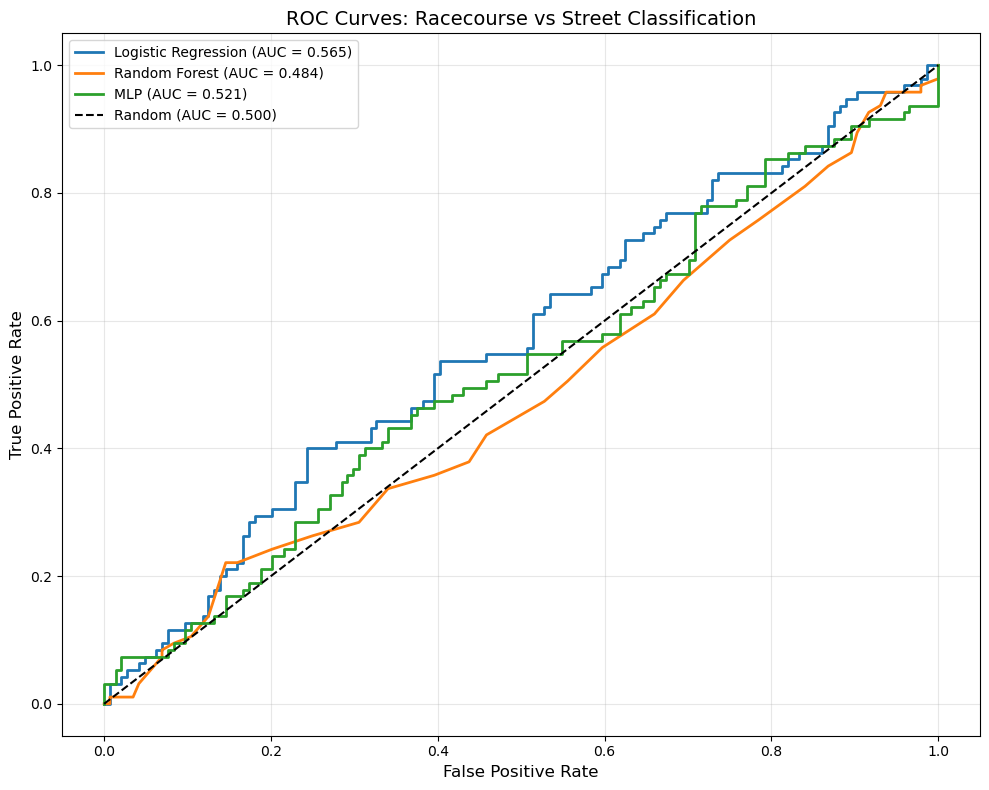

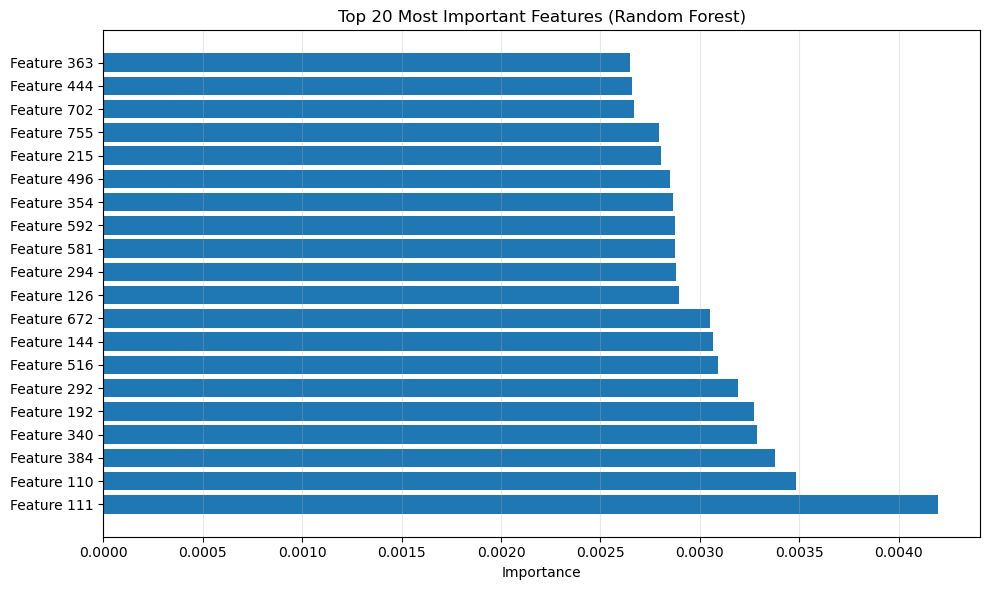


Top 5 most important features: [111 110 384 340 192]
Their importances: [0.00419907 0.00348114 0.00337849 0.00328515 0.00327157]

Summary:
Logistic Regression: AUC = 0.565
Random Forest: AUC = 0.484
MLP: AUC = 0.521

Above 0.5 indicates the model can distinguish between scenes


In [49]:
# Train/test split and classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.neural_network import MLPClassifier

if len(binary_embeddings) > 0:
    # Encode labels
    le = LabelEncoder()
    y = le.fit_transform(binary_labels)
    
    # Train/test split with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        binary_embeddings, y, 
        test_size=0.3, 
        random_state=42, 
        stratify=y
    )
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"Training set: {len(X_train)} samples ({np.sum(y_train==0)} racecourse, {np.sum(y_train==1)} street)")
    print(f"Test set: {len(X_test)} samples ({np.sum(y_test==0)} racecourse, {np.sum(y_test==1)} street)")
    
    # Try multiple classifiers
    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'MLP': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
    }
    
    results = {}
    
    for name, clf in classifiers.items():
        print(f"\n{'='*60}")
        print(f"Training {name}...")
        print(f"{'='*60}")
        
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_test_scaled)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, 'predict_proba') else None
        
        # Metrics
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=le.classes_))
        
        print(f"\nConfusion Matrix:")
        cm = confusion_matrix(y_test, y_pred)
        print(cm)
        
        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
            print(f"\nROC-AUC: {auc:.3f}")
            results[name] = {'auc': auc, 'model': clf, 'y_pred_proba': y_pred_proba}
        else:
            results[name] = {'auc': None, 'model': clf, 'y_pred_proba': None}
    
    # Plot ROC curves
    plt.figure(figsize=(10, 8))
    for name, result in results.items():
        if result['y_pred_proba'] is not None:
            fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
            plt.plot(fpr, tpr, label=f"{name} (AUC = {result['auc']:.3f})", linewidth=2)
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves: Racecourse vs Street Classification', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Feature importance (for Random Forest)
    if 'Random Forest' in results:
        rf = results['Random Forest']['model']
        importances = rf.feature_importances_
        top_indices = np.argsort(importances)[-20:][::-1]  # Top 20 features
        
        plt.figure(figsize=(10, 6))
        plt.barh(range(len(top_indices)), importances[top_indices])
        plt.yticks(range(len(top_indices)), [f'Feature {i}' for i in top_indices])
        plt.xlabel('Importance')
        plt.title('Top 20 Most Important Features (Random Forest)')
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()
        
        print(f"\nTop 5 most important features: {top_indices[:5]}")
        print(f"Their importances: {importances[top_indices[:5]]}")
    
    print(f"\n{'='*60}")
    print("Summary:")
    print(f"{'='*60}")
    for name, result in results.items():
        if result['auc'] is not None:
            print(f"{name}: AUC = {result['auc']:.3f}")
    print(f"\n{'Above 0.5' if max([r['auc'] for r in results.values() if r['auc'] is not None]) > 0.5 else 'All at/below 0.5'} indicates the model can distinguish between scenes")
else:
    print("No embeddings available for classification")


### Visualize Embedding Separability


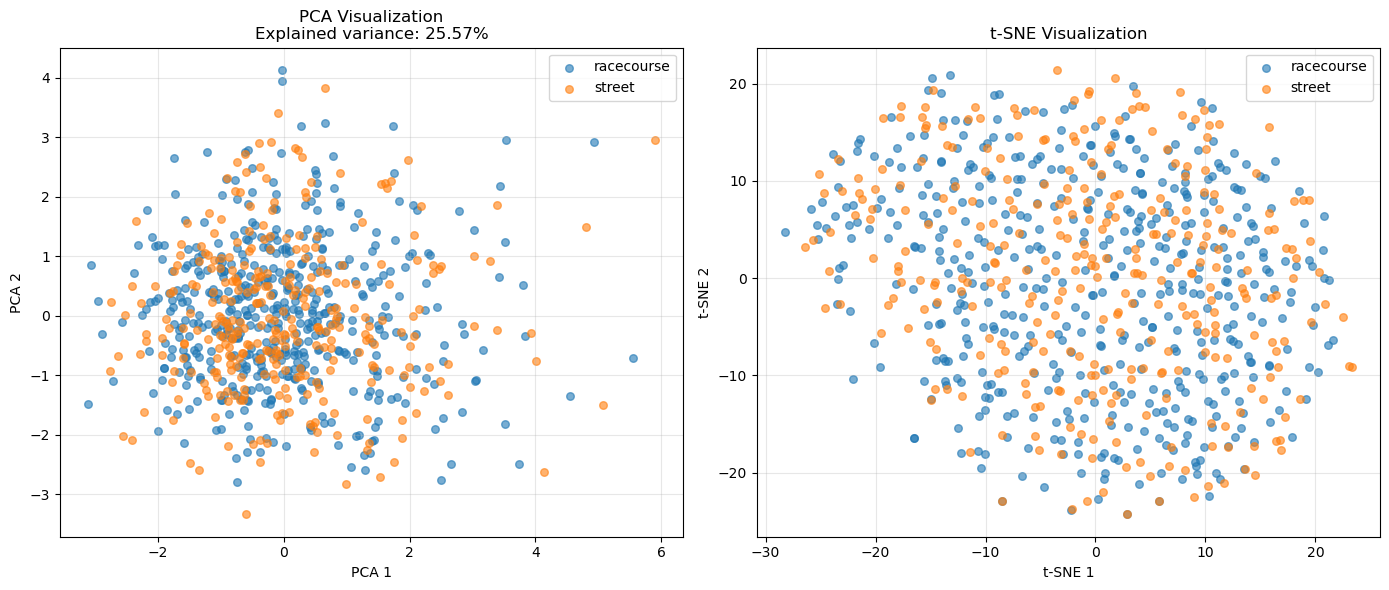


Separability Analysis:
Racecourse within-class distance: 4.973 ± 0.913
Street within-class distance: 5.069 ± 0.965
Between-class distance: 5.020 ± 0.939

Separability ratio (between/within): 1.000
Poor separation


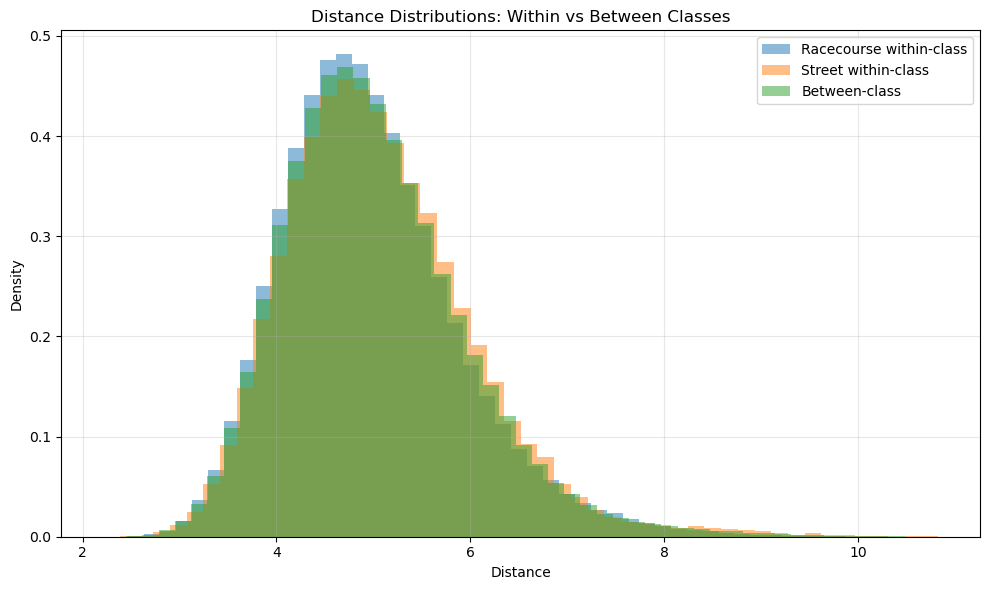

In [58]:
# Visualize embeddings in 2D to see separability
if len(binary_embeddings) > 0:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    
    # PCA visualization
    pca = PCA(n_components=2)
    emb_pca = pca.fit_transform(binary_embeddings)
    
    # t-SNE visualization (on subset if too many)
    if len(binary_embeddings) > 1000:
        subset_idx = np.random.choice(len(binary_embeddings), 500, replace=False)
        emb_subset = binary_embeddings[subset_idx]
        labels_subset = [binary_labels[i] for i in subset_idx]
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        emb_tsne = tsne.fit_transform(emb_subset)
    else:
        tsne = TSNE(n_components=2, random_state=42)
        emb_tsne = tsne.fit_transform(binary_embeddings)
        labels_subset = binary_labels
        subset_idx = np.arange(len(binary_embeddings))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # PCA plot
    ax = axes[0]
    for label in target_scenes:
        mask = np.array(binary_labels) == label
        ax.scatter(emb_pca[mask, 0], emb_pca[mask, 1], 
                  label=label, alpha=0.6, s=30)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.set_title(f'PCA Visualization\nExplained variance: {pca.explained_variance_ratio_.sum():.2%}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # t-SNE plot
    ax = axes[1]
    for label in target_scenes:
        mask = np.array(labels_subset) == label
        ax.scatter(emb_tsne[mask, 0], emb_tsne[mask, 1], 
                  label=label, alpha=0.6, s=30)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_title('t-SNE Visualization')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Compute separability metrics
    print("\nSeparability Analysis:")
    print(f"{'='*60}")
    
    # Within-class vs between-class distances
    from scipy.spatial.distance import cdist
    
    racecourse_emb = binary_embeddings[np.array(binary_labels) == 'racecourse']
    street_emb = binary_embeddings[np.array(binary_labels) == 'street']
    
    # Within-class distances
    racecourse_within = cdist(racecourse_emb, racecourse_emb)
    racecourse_within = racecourse_within[np.triu_indices(len(racecourse_emb), k=1)]
    
    street_within = cdist(street_emb, street_emb)
    street_within = street_within[np.triu_indices(len(street_emb), k=1)]
    
    # Between-class distances
    between = cdist(racecourse_emb, street_emb)
    
    print(f"Racecourse within-class distance: {np.mean(racecourse_within):.3f} ± {np.std(racecourse_within):.3f}")
    print(f"Street within-class distance: {np.mean(street_within):.3f} ± {np.std(street_within):.3f}")
    print(f"Between-class distance: {np.mean(between):.3f} ± {np.std(between):.3f}")
    
    # Separability ratio (higher is better)
    within_avg = (np.mean(racecourse_within) + np.mean(street_within)) / 2
    separability = np.mean(between) / within_avg
    print(f"\nSeparability ratio (between/within): {separability:.3f}")
    print(f"{'Good separation' if separability > 1.2 else 'Poor separation' if separability < 1.0 else 'Moderate separation'}")
    
    # Plot distance distributions
    plt.figure(figsize=(10, 6))
    plt.hist(racecourse_within, bins=50, alpha=0.5, label='Racecourse within-class', density=True)
    plt.hist(street_within, bins=50, alpha=0.5, label='Street within-class', density=True)
    plt.hist(between.flatten(), bins=50, alpha=0.5, label='Between-class', density=True)
    plt.xlabel('Distance')
    plt.ylabel('Density')
    plt.title('Distance Distributions: Within vs Between Classes')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No embeddings to visualize")


In [ ]:
# Diagnostic: Check embedding statistics
print(f"Embedding mean: {binary_embeddings.mean(axis=0)[:10]}")  # First 10 dims
print(f"Embedding std: {binary_embeddings.std(axis=0)[:10]}")
print(f"Embedding range: [{binary_embeddings.min():.3f}, {binary_embeddings.max():.3f}]")

# Check if embeddings are too similar
from sklearn.metrics.pairwise import cosine_similarity
all_similarities = cosine_similarity(binary_embeddings)
print(f"Mean pairwise similarity: {all_similarities[np.triu_indices(len(binary_embeddings), k=1)].mean():.3f}")

Embedding mean: [-1.3995467   1.0394372   0.5831496   0.49880433  1.1821964  -1.7282133
  1.499431    0.78784037  1.7563151   0.9593463 ]
Embedding std: [0.20050682 0.12985335 0.08237738 0.11079476 0.05620179 0.2112982
 0.09637268 0.04260937 0.0728467  0.08839198]
Embedding range: [-10.779, 2.694]
Mean pairwise similarity: 0.990


In [60]:
# Check if BrainBERT outputs vary BEFORE averaging
electrode_outputs = []  # Store individual electrode outputs
for window in binary_windows['racecourse'][:10]:  # Sample 10 windows
    for electrode_idx in range(min(5, window.shape[0])):  # First 5 electrodes
        wav = window[electrode_idx, :]
        f, t, stft_spec = get_stft(wav, fs=2048, clip_fs=40, 
                                  nperseg=400, noverlap=350, 
                                  normalizing="zscore", return_onesided=True)
        inputs = torch.FloatTensor(stft_spec).unsqueeze(0).transpose(1, 2).to(device)
        mask = torch.zeros((inputs.shape[:2]), dtype=torch.bool).to(device)
        
        with torch.no_grad():
            out = brainbert_model.forward(inputs, mask, intermediate_rep=True)
            middle = out.shape[1]
            if middle > 10:
                embed = out[:, middle-5:middle+5, :].mean(dim=1)
            else:
                embed = out.mean(dim=1)
            electrode_outputs.append(embed.cpu().numpy().squeeze())

electrode_outputs = np.array(electrode_outputs)
print(f"BrainBERT output variance (before pooling):")
print(f"  Mean std across samples: {electrode_outputs.std(axis=0).mean():.3f}")
print(f"  Pairwise similarity: {cosine_similarity(electrode_outputs)[np.triu_indices(len(electrode_outputs), k=1)].mean():.3f}")

# Check raw signal variance
racecourse_sample = binary_windows['racecourse'][0]
street_sample = binary_windows['street'][0]
print(f"\nRaw signal difference:")
print(f"  Mean difference: {np.abs(racecourse_sample - street_sample).mean():.3f}")
print(f"  Correlation: {np.corrcoef(racecourse_sample.flatten(), street_sample.flatten())[0,1]:.3f}")

BrainBERT output variance (before pooling):
  Mean std across samples: 0.486
  Pairwise similarity: 0.854

Raw signal difference:
  Mean difference: 10730.828
  Correlation: 0.090


Demo + For all scene embeddings

In [ ]:
from omegaconf import OmegaConf
ckpt_path = "pretrained_weights/stft_large_pretrained.pth"
cfg = OmegaConf.create({"upstream_ckpt": ckpt_path})
model = build_model(cfg)
model.to('cuda')
init_state = torch.load(ckpt_path)
load_model_weights(model, init_state['model'], False)

C:\Users\User\AppData\Local\Temp\ipykernel_24196\4085520086.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  init_state = torch.load(ckpt_path)
c:\Users\User\.conda\envs\

In [48]:
# Instead of averaging electrodes BEFORE BrainBERT, process each separately and pool AFTER
if brainbert_model is not None and scene_windows:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    for label, windows in scene_windows.items():
        scene_embeddings[label] = []
        
        for window in windows:
            # window is [C, T] - process each electrode separately
            electrode_embeddings = []
            
            for electrode_idx in range(window.shape[0]):
                wav = window[electrode_idx, :]  # [T] - single electrode
                
                # Compute STFT
                f, t, stft_spec = get_stft(wav, fs=2048, clip_fs=40, 
                                          nperseg=400, noverlap=350, 
                                          normalizing="zscore", 
                                          return_onesided=True)
                
                # Prepare input
                inputs = torch.FloatTensor(stft_spec).unsqueeze(0).transpose(1, 2).to(device)
                mask = torch.zeros((inputs.shape[:2]), dtype=torch.bool).to(device)
                
                # Forward pass
                with torch.no_grad():
                    out = brainbert_model.forward(inputs, mask, intermediate_rep=True)
                
                # Use middle time steps (like spec_pretrained.py does)
                middle = out.shape[1]
                embed = out[:, middle-5:middle+5, :].mean(dim=1)  # [1, hidden_dim]
                electrode_embeddings.append(embed.cpu().numpy())
            
            # Average across electrodes AFTER getting embeddings
            embedding = np.mean(electrode_embeddings, axis=0).squeeze()
            scene_embeddings[label].append(embedding)
        
        print(f"Encoded {len(scene_embeddings[label])} instances of '{label}'")

Encoded 481 instances of 'racecourse'
Encoded 47 instances of 'desert road'
Encoded 12 instances of 'desert/vegetation'


KeyboardInterrupt: 

In [49]:
# Select electrodes from visual/temporal regions instead of all
# Use localization data to filter electrodes
loc_df = pd.read_csv(os.path.join(root_dir, "localization", "elec_coords_full.csv"))
sub_loc = loc_df[loc_df['Subject'] == f'sub_{sub_id}']

# Filter to visual/temporal regions
visual_regions = ['G_oc-temp_med-Parahip', 'G_temporal_middle', 'S_temporal_sup', 
                  'O1aIb', 'O1bId']  # Add relevant regions
visual_elec_names = sub_loc[sub_loc['Region'].str.contains('|'.join(visual_regions), na=False)]['Electrode'].tolist()

# Match electrode labels to indices
with h5py.File(neural_data_file, 'r') as h5f:
    all_electrode_keys = list(h5f['data'].keys())
    # Map electrode labels to H5 keys
    use_electrodes = [k for k in all_electrode_keys if any(e in str(k) for e in visual_elec_names)]

In [50]:
# Instead of averaging, try max pooling or using specific time steps
with torch.no_grad():
    out = brainbert_model.forward(inputs, mask, intermediate_rep=True)
    # Try max pooling instead of mean
    embedding = out.max(dim=1)[0].cpu().numpy()  # Max pooling
    # OR use middle time steps
    # middle = out.shape[1]
    # embedding = out[:, middle, :].cpu().numpy()  # Single time step

In [51]:
# Diagnostic: Check if embeddings have any variance at all
if scene_embeddings:
    sample_emb = scene_embeddings[list(scene_embeddings.keys())[0]][0]
    print(f"Embedding shape: {sample_emb.shape}")
    print(f"Embedding range: [{sample_emb.min():.3f}, {sample_emb.max():.3f}]")
    print(f"Embedding std: {sample_emb.std():.3f}")
    
    # Check if all embeddings are nearly identical
    all_embs = np.vstack([np.array(embeddings) for embeddings in scene_embeddings.values()])
    print(f"\nAll embeddings - Mean std: {all_embs.std(axis=0).mean():.3f}")
    print(f"All embeddings - Range: [{all_embs.min():.3f}, {all_embs.max():.3f}]")

Embedding shape: (768,)
Embedding range: [-10.494, 2.371]
Embedding std: 0.860

All embeddings - Mean std: 0.171
All embeddings - Range: [-10.883, 3.052]


In [13]:
# Import STFT transform (from brainbert_starter.ipynb)
from scipy import signal
# import torch

def compute_stft(data, fs=2048, nperseg=256, noverlap=128):
    """
    Compute STFT for multi-channel data
    data: [C, T] -> [C, freq_bins, time_frames]
    """
    f, t, Zxx = signal.stft(data, fs=fs, nperseg=nperseg, noverlap=noverlap, 
                             axis=-1, return_onesided=True)
    # Return magnitude spectrogram: [C, freq, time]
    return np.abs(Zxx)

# Transform windows to STFT
scene_stfts = {}
for label, windows in scene_windows.items():
    scene_stfts[label] = [compute_stft(w) for w in windows]

# Check dimensions
sample_stft = list(scene_stfts.values())[0][0]
print(f"STFT shape per window: {sample_stft.shape}")  # Should be [C, freq, time]

# Load BrainBERT (from brainbert_starter.ipynb)
# Copy the BrainBERT class and loading code from brainbert_starter.ipynb
# Then encode windows
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
brainbert_model.eval()

scene_embeddings = {}  # {label: [list of embeddings]}
with torch.no_grad():
    for label, stfts in scene_stfts.items():
        scene_embeddings[label] = []
        
        for stft in stfts:
            # stft is [C, freq, time], need to prepare for BrainBERT
            # BrainBERT expects [batch, freq, time] - we can average across channels
            # or process each channel separately and average embeddings
            stft_avg = stft.mean(axis=0)  # [freq, time] - average across channels
            
            # Convert to tensor and add batch dim: [1, freq, time]
            x = torch.tensor(stft_avg, dtype=torch.float32).unsqueeze(0).to(device)
            
            # Get BrainBERT embedding
            emb = brainbert_model(x)  # [1, d_model]
            scene_embeddings[label].append(emb.cpu().numpy().squeeze())
        
        print(f"Encoded {len(scene_embeddings[label])} instances of '{label}'")

NameError: name 'scene_windows' is not defined

In [47]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Compute intra-scene similarity (same scene, different times)
# vs inter-scene similarity (different scenes)

results = {}
for label, embeddings in scene_embeddings.items():
    if len(embeddings) < 2:
        continue
    
    embs = np.array(embeddings)  # [N_instances, d_model]
    
    # Intra-scene similarity (all pairs within same scene)
    sim_matrix = cosine_similarity(embs)
    
    # Get upper triangle (excluding diagonal)
    n = len(embs)
    intra_similarities = []
    for i in range(n):
        for j in range(i+1, n):
            intra_similarities.append(sim_matrix[i, j])
    
    results[label] = {
        'embeddings': embs,
        'intra_similarity_mean': np.mean(intra_similarities),
        'intra_similarity_std': np.std(intra_similarities),
        'intra_similarities': intra_similarities,
        'n_instances': n
    }
    
    print(f"'{label}': {n} instances, mean intra-scene similarity = {np.mean(intra_similarities):.3f}")

# Compare intra-scene vs inter-scene similarity
all_intra = []
all_inter = []

for label1, data1 in results.items():
    all_intra.extend(data1['intra_similarities'])
    
    # Compare with other scenes
    for label2, data2 in results.items():
        if label1 == label2:
            continue
        
        # Compute inter-scene similarity
        inter_sim = cosine_similarity(data1['embeddings'], data2['embeddings'])
        all_inter.extend(inter_sim.flatten().tolist())

print(f"\nIntra-scene similarity: {np.mean(all_intra):.3f} ± {np.std(all_intra):.3f}")
print(f"Inter-scene similarity: {np.mean(all_inter):.3f} ± {np.std(all_inter):.3f}")

'racecourse': 481 instances, mean intra-scene similarity = 0.992
'desert road': 47 instances, mean intra-scene similarity = 0.993
'desert/vegetation': 12 instances, mean intra-scene similarity = 0.995
'street': 315 instances, mean intra-scene similarity = 0.993
'restaurant patio': 26 instances, mean intra-scene similarity = 0.994
'palace': 99 instances, mean intra-scene similarity = 0.994
'sky': 45 instances, mean intra-scene similarity = 0.993
'bar': 7 instances, mean intra-scene similarity = 0.993
'boat deck': 26 instances, mean intra-scene similarity = 0.994
'river': 4 instances, mean intra-scene similarity = 0.993

Intra-scene similarity: 0.993 ± 0.005
Inter-scene similarity: 0.993 ± 0.005
